# Day 6.3: Lab - Decision Tree Implementation & Tuning

## Table of Contents
- [Introduction](#introduction)
- [Setting Up the Environment](#setting-up-the-environment)
- [Loading and Preparing the Breast Cancer Dataset](#loading-and-preparing-the-breast-cancer-dataset)
- [Basic Decision Tree Classifier Implementation](#basic-decision-tree-classifier-implementation)
  - [Training and Evaluation](#training-and-evaluation)
  - [Visualizing the Default Tree](#visualizing-the-default-tree)
- [Addressing Overfitting](#addressing-overfitting)
  - [Testing Different max_depth Values](#testing-different-max_depth-values)
  - [Effect of min_samples_split and min_samples_leaf](#effect-of-min_samples_split-and-min_samples_leaf)
  - [Cost-Complexity Pruning (ccp_alpha)](#cost-complexity-pruning-ccp_alpha)
  - [Visualizing Performance vs. Complexity](#visualizing-performance-vs-complexity)
- [Handling Categorical Features](#handling-categorical-features)
  - [One-Hot Encoding](#one-hot-encoding)
  - [Ordinal Encoding](#ordinal-encoding)
  - [Impact on Tree Performance](#impact-on-tree-performance)
- [Model Interpretation](#model-interpretation)
  - [Feature Importance Analysis](#feature-importance-analysis)
  - [Decision Boundaries Visualization (2D example)](#decision-boundaries-visualization-2d-example)
  - [Interpreting Decision Paths](#interpreting-decision-paths)
- [Comparing Different Criteria (Gini vs. Entropy)](#comparing-different-criteria-gini-vs-entropy)
- [Analysis of Misclassified Samples](#analysis-of-misclassified-samples)
- [Summary and Next Steps](#summary-and-next-steps)

## Introduction

Welcome to our lab on Decision Tree implementation and tuning! In this practical session, we'll implement the concepts covered in the previous two sessions, focusing on:

1. Building and evaluating a basic Decision Tree classifier
2. Addressing overfitting through various complexity control techniques
3. Understanding and visualizing feature importance
4. Comparing different splitting criteria
5. Analyzing model performance and misclassifications

Let's start by setting up our environment and loading the dataset.

## Setting Up the Environment

First, let's import the necessary libraries:

In [2]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

# Set random seed for reproducibility
np.random.seed(42)

# Set up matplotlib for better visualization
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("--- Day 6.3 Lab: Decision Tree Implementation & Tuning ---")

--- Day 6.3 Lab: Decision Tree Implementation & Tuning ---


## Loading and Preparing the Breast Cancer Dataset

We'll use the Breast Cancer Wisconsin dataset, which is commonly used for binary classification tasks. The dataset contains features computed from a digitized image of a fine needle aspirate (FNA) of a breast mass, describing characteristics of the cell nuclei present in the image.

In [3]:
# Load the Breast Cancer dataset
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target
feature_names = cancer.feature_names
target_names = cancer.target_names

# Create a DataFrame for better data handling
cancer_df = pd.DataFrame(X, columns=feature_names)
cancer_df['target'] = y
cancer_df['diagnosis'] = [target_names[target] for target in y]

# Display basic information about the dataset
print("\n--- Dataset Information ---")
print(f"Dataset shape: {X.shape}")
print(f"Number of classes: {len(target_names)}")
print(f"Class distribution: {np.bincount(y)}")
print(f"Class names: {target_names}")
print("\nFeatures:")
for i, feature in enumerate(feature_names):
    print(f"  {i+1}. {feature}")


--- Dataset Information ---
Dataset shape: (569, 30)
Number of classes: 2
Class distribution: [212 357]
Class names: ['malignant' 'benign']

Features:
  1. mean radius
  2. mean texture
  3. mean perimeter
  4. mean area
  5. mean smoothness
  6. mean compactness
  7. mean concavity
  8. mean concave points
  9. mean symmetry
  10. mean fractal dimension
  11. radius error
  12. texture error
  13. perimeter error
  14. area error
  15. smoothness error
  16. compactness error
  17. concavity error
  18. concave points error
  19. symmetry error
  20. fractal dimension error
  21. worst radius
  22. worst texture
  23. worst perimeter
  24. worst area
  25. worst smoothness
  26. worst compactness
  27. worst concavity
  28. worst concave points
  29. worst symmetry
  30. worst fractal dimension


In [4]:
# Display first few rows of the DataFrame
print("\nFirst 5 rows of the dataset:")
cancer_df.head()


First 5 rows of the dataset:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


In [5]:
# Display basic statistics
print("\nBasic statistics:")
cancer_df.describe().T


Basic statistics:


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [6]:
# Check for missing values
print("\nMissing values:")
print(cancer_df.isnull().sum().sum())


Missing values:
0


In [7]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

# Scale the features 
# Note: Decision Trees are not sensitive to feature scaling, but we'll scale anyway
# for consistency with other algorithms and to facilitate visualizations
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nData loaded, split, and scaled.")
print(f"Training set shape: {X_train_scaled.shape}")
print(f"Test set shape: {X_test_scaled.shape}")


Data loaded, split, and scaled.
Training set shape: (398, 30)
Test set shape: (171, 30)


Let's also visualize some key features of the dataset to better understand it:

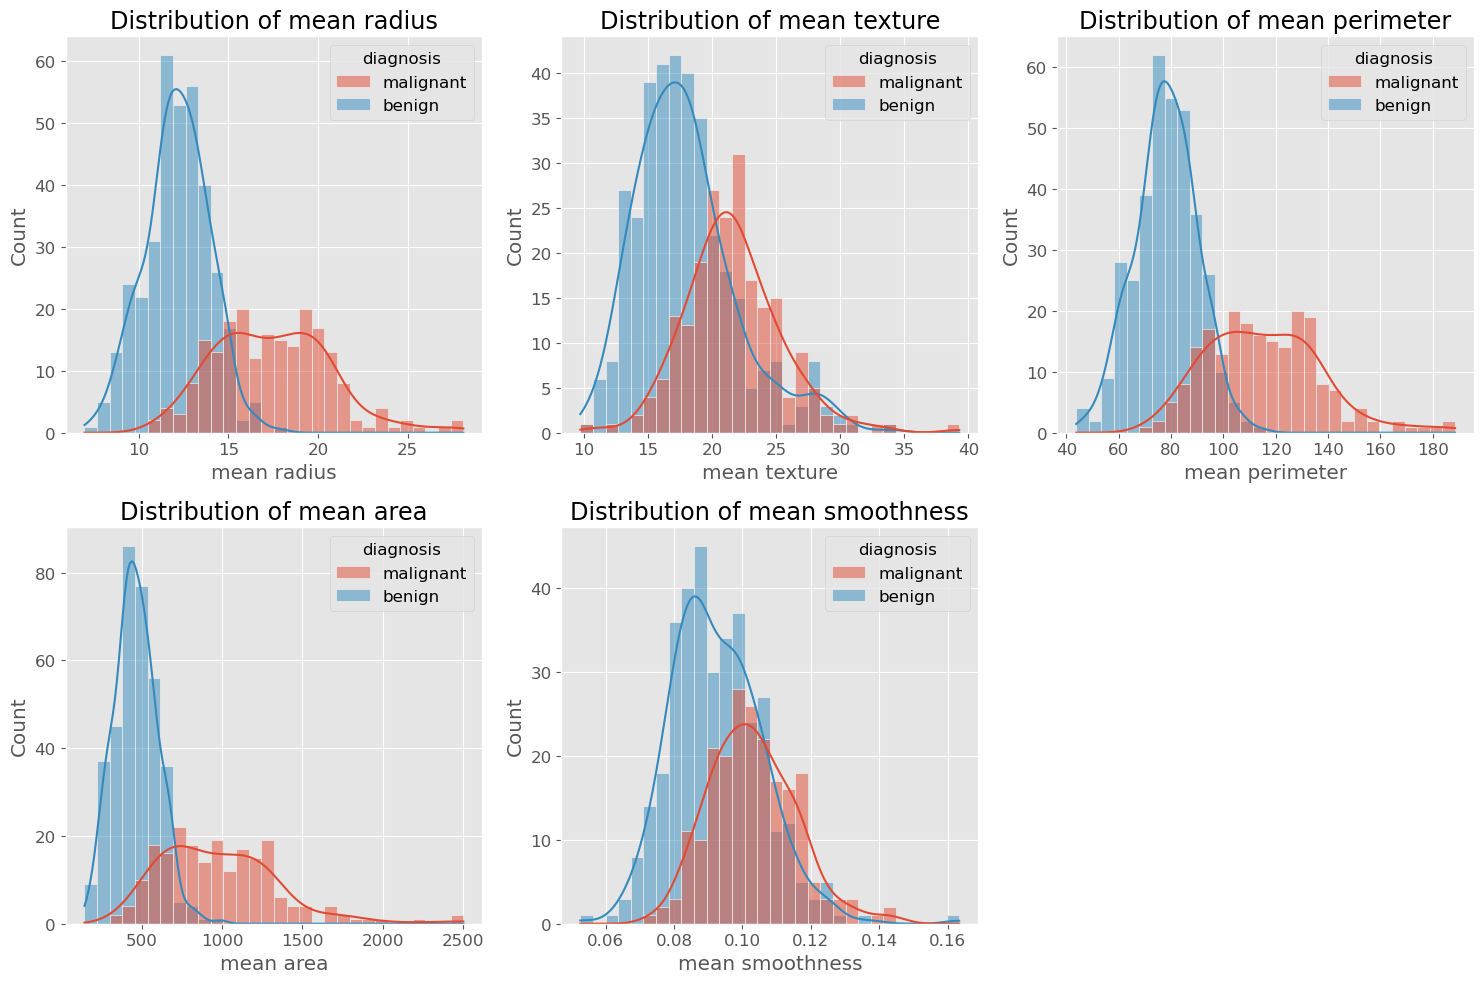

In [8]:
# Visualize the distribution of a few key features
plt.figure(figsize=(15, 10))

# Select a subset of informative features
selected_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness']

for i, feature in enumerate(selected_features):
    plt.subplot(2, 3, i+1)
    sns.histplot(data=cancer_df, x=feature, hue='diagnosis', bins=30, kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    
plt.tight_layout()
plt.show()

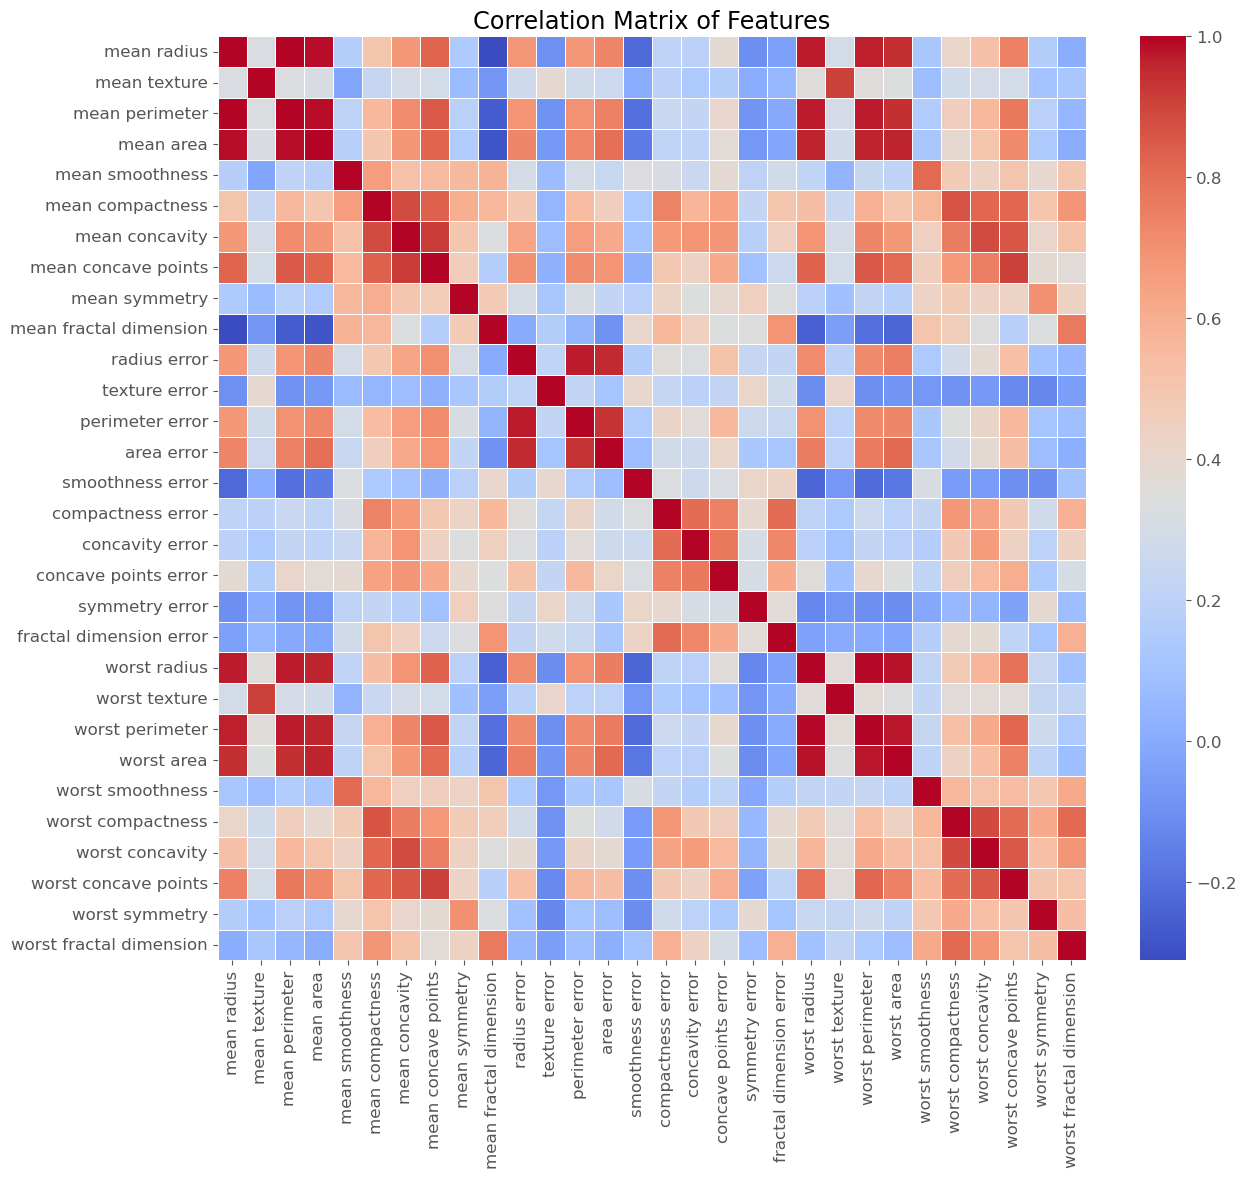

In [9]:
# Correlation matrix of features
plt.figure(figsize=(14, 12))
correlation_matrix = cancer_df.iloc[:, :-2].corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Features')
plt.show()

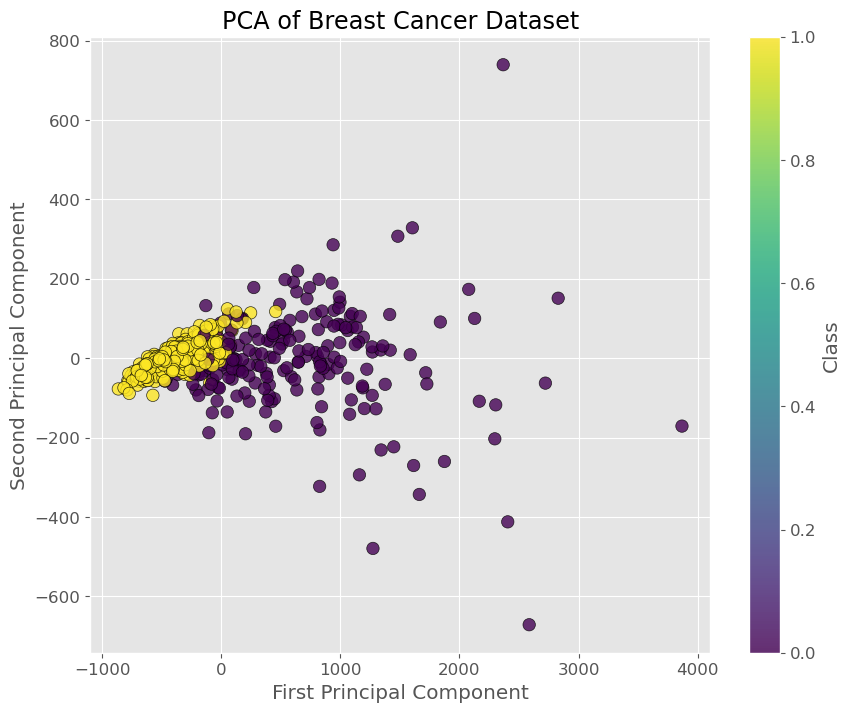

Variance explained by the first two components: 1.00


In [10]:
# PCA visualization to see if classes are separable
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', 
            edgecolor='k', s=80, alpha=0.8)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('PCA of Breast Cancer Dataset')
plt.colorbar(scatter, label='Class')
plt.show()

print(f"Variance explained by the first two components: {sum(pca.explained_variance_ratio_):.2f}")

### Knowledge Check: Dataset Exploration
1. How many features and samples are in the Breast Cancer dataset?
2. What's the distribution of the target classes? Is the dataset balanced?
3. Based on the feature distributions, which features appear to be most discriminative between benign and malignant tumors?
4. What does the PCA visualization tell us about the separability of the classes?
5. Why might feature scaling be necessary for PCA but not for Decision Trees?

## Basic Decision Tree Classifier Implementation

Now, let's implement a basic Decision Tree classifier and see how it performs.

In [11]:
# Create and train a Decision Tree with default parameters
dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train_scaled, y_train)

# Make predictions on training and test sets
y_train_pred = dt_default.predict(X_train_scaled)
y_test_pred = dt_default.predict(X_test_scaled)

# Evaluate the model
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("\n--- Default Decision Tree Performance ---")
print(f"Training accuracy: {train_accuracy:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Accuracy gap (train - test): {train_accuracy - test_accuracy:.4f}")


--- Default Decision Tree Performance ---
Training accuracy: 1.0000
Test accuracy: 0.9181
Accuracy gap (train - test): 0.0819


In [12]:
# Show more detailed metrics
print("\nClassification Report on Test Set:")
print(classification_report(y_test, y_test_pred, target_names=target_names))


Classification Report on Test Set:
              precision    recall  f1-score   support

   malignant       0.89      0.89      0.89        64
      benign       0.93      0.93      0.93       107

    accuracy                           0.92       171
   macro avg       0.91      0.91      0.91       171
weighted avg       0.92      0.92      0.92       171



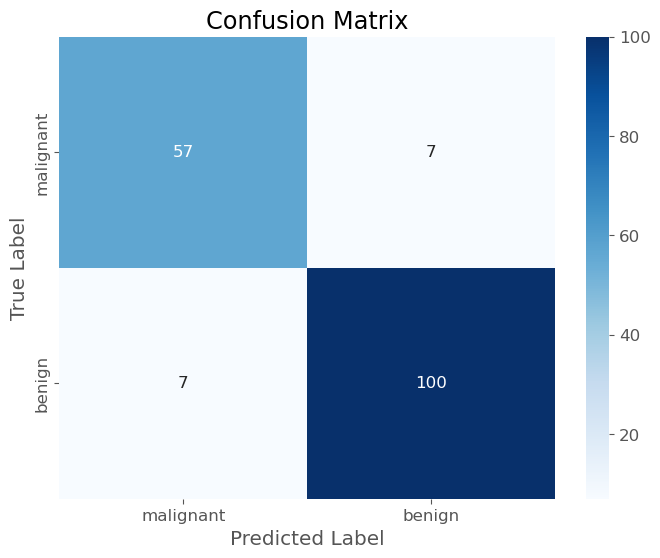

In [13]:
# Display confusion matrix
conf_matrix = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [14]:
# Check tree characteristics
tree_depth = dt_default.get_depth()
leaf_count = dt_default.get_n_leaves()

print(f"\nTree depth: {tree_depth}")
print(f"Number of leaves: {leaf_count}")


Tree depth: 6
Number of leaves: 16


### Visualizing the Default Tree

Let's visualize the structure of our default tree (limiting depth for readability):

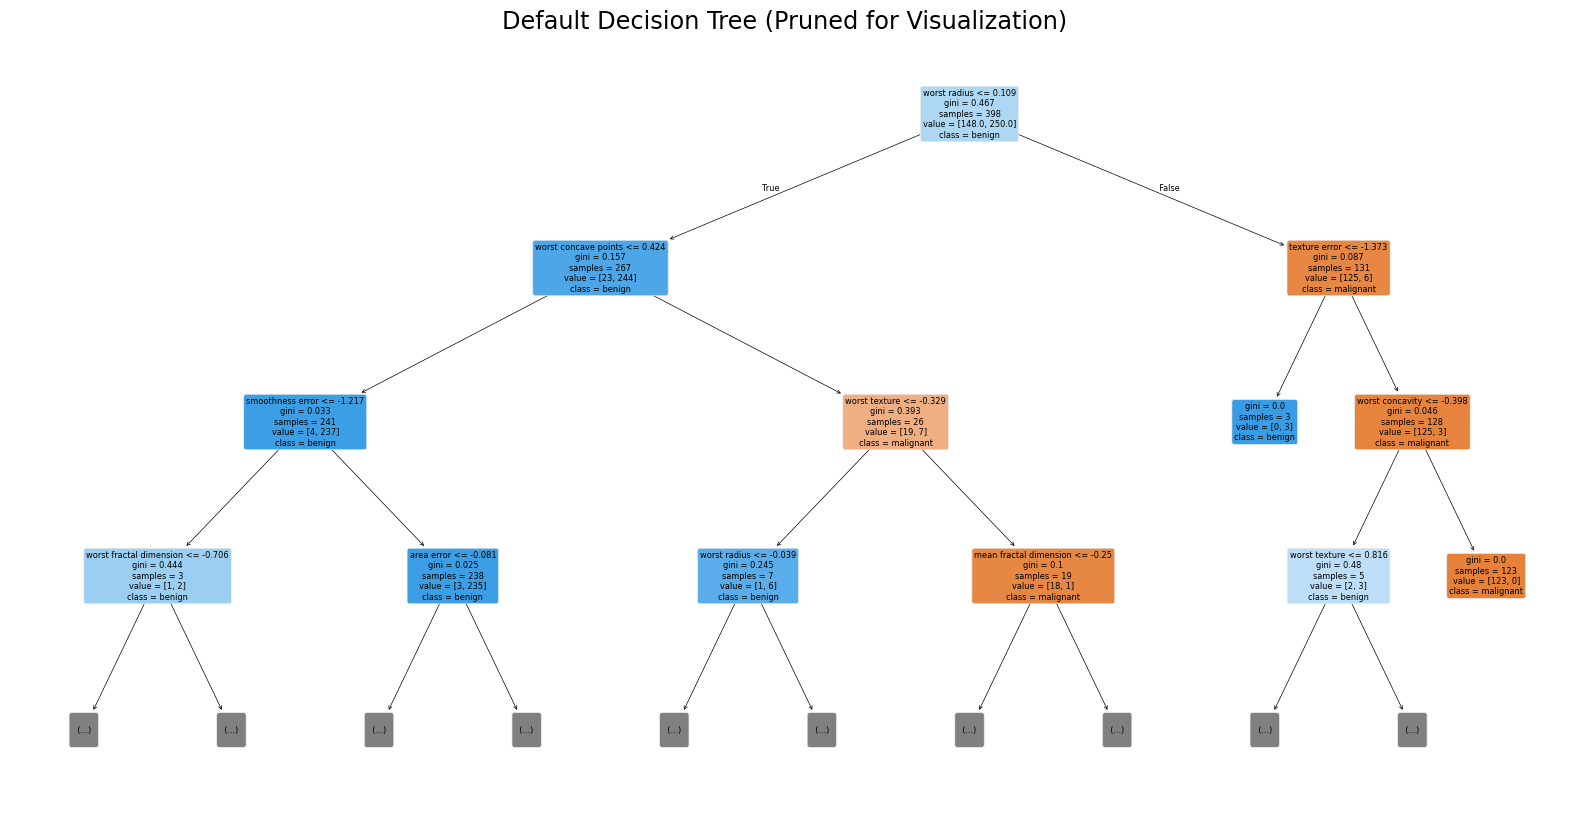

In [15]:
# Visualize the decision tree (limiting depth for readability)
plt.figure(figsize=(20, 10))
plot_tree(dt_default, 
          max_depth=3,  # Limit visualization depth for readability
          filled=True,
          rounded=True,
          feature_names=feature_names,
          class_names=target_names)
plt.title("Default Decision Tree (Pruned for Visualization)")
plt.show()

In [16]:
# Print text representation for better understanding
tree_text = export_text(dt_default, 
                       feature_names=list(feature_names),
                       show_weights=True,
                       max_depth=3)
print("\nText Representation of the Tree (Limited to Depth 3):")
print(tree_text)


Text Representation of the Tree (Limited to Depth 3):
|--- worst radius <= 0.11
|   |--- worst concave points <= 0.42
|   |   |--- smoothness error <= -1.22
|   |   |   |--- worst fractal dimension <= -0.71
|   |   |   |   |--- weights: [0.00, 2.00] class: 1
|   |   |   |--- worst fractal dimension >  -0.71
|   |   |   |   |--- weights: [1.00, 0.00] class: 0
|   |   |--- smoothness error >  -1.22
|   |   |   |--- area error <= -0.08
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- area error >  -0.08
|   |   |   |   |--- truncated branch of depth 3
|   |--- worst concave points >  0.42
|   |   |--- worst texture <= -0.33
|   |   |   |--- worst radius <= -0.04
|   |   |   |   |--- weights: [0.00, 6.00] class: 1
|   |   |   |--- worst radius >  -0.04
|   |   |   |   |--- weights: [1.00, 0.00] class: 0
|   |   |--- worst texture >  -0.33
|   |   |   |--- mean fractal dimension <= -0.25
|   |   |   |   |--- weights: [0.00, 1.00] class: 1
|   |   |   |--- mean fractal dime

### Knowledge Check: Basic Tree Implementation
1. What does the performance gap between training and test accuracy suggest about our default tree?
2. How would you describe the complexity of the default tree based on its depth and number of leaves?
3. Looking at the confusion matrix, which type of error (false positive or false negative) is more common, and why might this matter?
4. From the visualized tree, which feature(s) appear at the top levels, and what does this suggest?
5. What implications might a tree with hundreds of leaves have for generalization?

## Addressing Overfitting

As we've seen, decision trees tend to overfit when not properly constrained. Let's explore different methods to control overfitting.

### Testing Different max_depth Values

In [17]:
# Test different max_depth values
max_depths = [1, 2, 3, 5, 10, 15, 20, None]
train_scores = []
test_scores = []
complexity_measures = []

for depth in max_depths:
    # Train model with specific max_depth
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train_scaled, y_train)
    
    # Get predictions and accuracies
    train_pred = dt.predict(X_train_scaled)
    test_pred = dt.predict(X_test_scaled)
    
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    
    # Store results
    train_scores.append(train_acc)
    test_scores.append(test_acc)
    
    # Store complexity measures
    actual_depth = dt.get_depth()
    n_leaves = dt.get_n_leaves()
    complexity_measures.append((actual_depth, n_leaves))
    
    print(f"\nmax_depth={depth}:")
    print(f"  Training accuracy: {train_acc:.4f}")
    print(f"  Test accuracy: {test_acc:.4f}")
    print(f"  Gap: {train_acc - test_acc:.4f}")
    print(f"  Actual depth: {actual_depth}, Leaves: {n_leaves}")


max_depth=1:
  Training accuracy: 0.9271
  Test accuracy: 0.9123
  Gap: 0.0149
  Actual depth: 1, Leaves: 2

max_depth=2:
  Training accuracy: 0.9648
  Test accuracy: 0.9181
  Gap: 0.0467
  Actual depth: 2, Leaves: 4

max_depth=3:
  Training accuracy: 0.9799
  Test accuracy: 0.9240
  Gap: 0.0559
  Actual depth: 3, Leaves: 7

max_depth=5:
  Training accuracy: 0.9950
  Test accuracy: 0.9298
  Gap: 0.0652
  Actual depth: 5, Leaves: 14

max_depth=10:
  Training accuracy: 1.0000
  Test accuracy: 0.9181
  Gap: 0.0819
  Actual depth: 6, Leaves: 16

max_depth=15:
  Training accuracy: 1.0000
  Test accuracy: 0.9181
  Gap: 0.0819
  Actual depth: 6, Leaves: 16

max_depth=20:
  Training accuracy: 1.0000
  Test accuracy: 0.9181
  Gap: 0.0819
  Actual depth: 6, Leaves: 16

max_depth=None:
  Training accuracy: 1.0000
  Test accuracy: 0.9181
  Gap: 0.0819
  Actual depth: 6, Leaves: 16


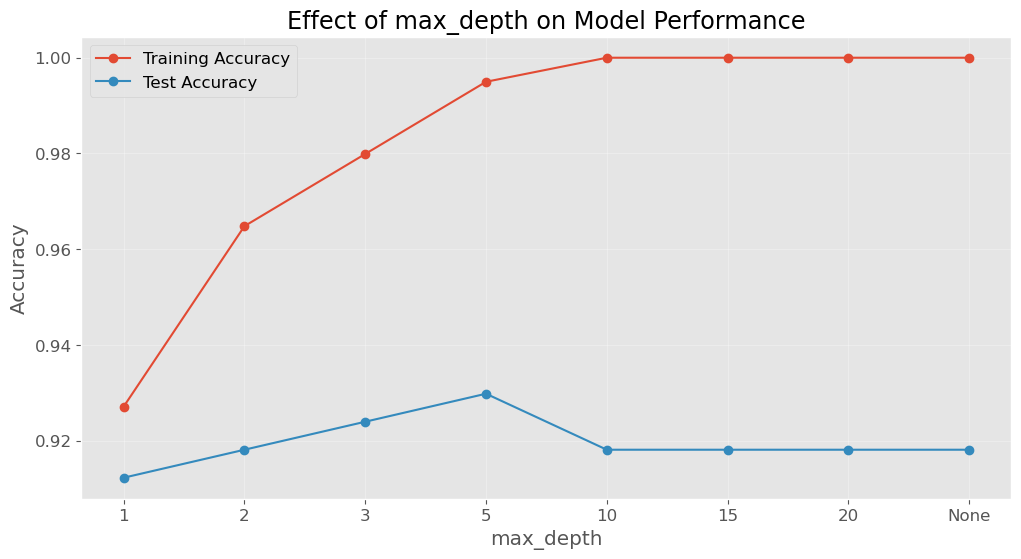

In [18]:
# Visualize the effect of max_depth
plt.figure(figsize=(12, 6))
plt.plot(range(len(max_depths)), train_scores, 'o-', label='Training Accuracy')
plt.plot(range(len(max_depths)), test_scores, 'o-', label='Test Accuracy')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Effect of max_depth on Model Performance')
plt.xticks(range(len(max_depths)), [str(d) for d in max_depths])
plt.grid(True, alpha=0.3)
plt.legend()

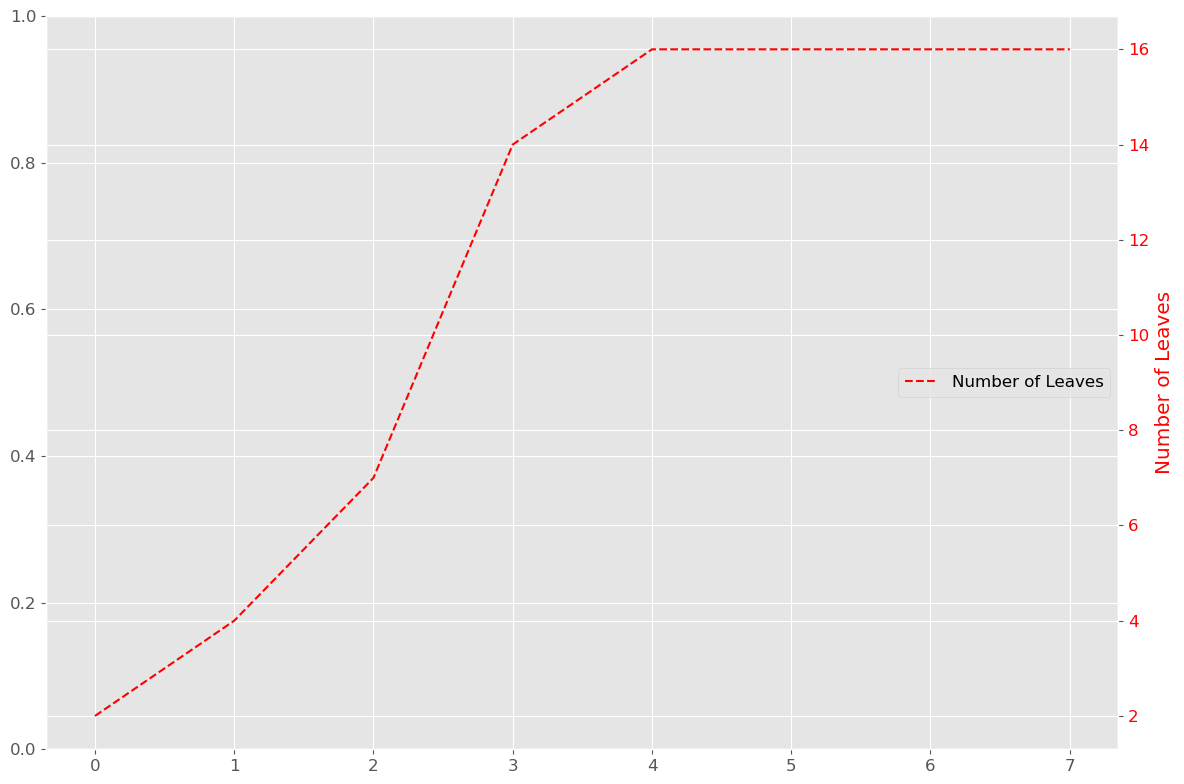

In [19]:
# Add a second y-axis for complexity measures
ax2 = plt.twinx()
depths, leaves = zip(*complexity_measures)
ax2.plot(range(len(max_depths)), leaves, 'r--', label='Number of Leaves')
ax2.set_ylabel('Number of Leaves', color='r')
ax2.tick_params(axis='y', labelcolor='r')
ax2.legend(loc='center right')

plt.tight_layout()
plt.show()

In [20]:
# Find optimal max_depth based on test accuracy
best_depth_idx = np.argmax(test_scores)
best_depth = max_depths[best_depth_idx]
print(f"\nBest max_depth: {best_depth}")
print(f"Test accuracy with best max_depth: {test_scores[best_depth_idx]:.4f}")


Best max_depth: 5
Test accuracy with best max_depth: 0.9298


### Effect of min_samples_split and min_samples_leaf

In [21]:
# Test different min_samples_split values
min_samples_splits = [2, 5, 10, 20, 50, 100]
train_scores_mss = []
test_scores_mss = []

for min_samples in min_samples_splits:
    # Train model with specific min_samples_split
    dt = DecisionTreeClassifier(min_samples_split=min_samples, random_state=42)
    dt.fit(X_train_scaled, y_train)
    
    # Calculate accuracies
    train_acc = accuracy_score(y_train, dt.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, dt.predict(X_test_scaled))
    
    train_scores_mss.append(train_acc)
    test_scores_mss.append(test_acc)
    
    print(f"\n min_samples_split={min_samples}:")
    print(f"  Training accuracy: {train_acc:.4f}")
    print(f"  Test accuracy: {test_acc:.4f}")
    print(f"  Depth: {dt.get_depth()}, Leaves: {dt.get_n_leaves()}")


 min_samples_split=2:
  Training accuracy: 1.0000
  Test accuracy: 0.9181
  Depth: 6, Leaves: 16

 min_samples_split=5:
  Training accuracy: 0.9975
  Test accuracy: 0.9357
  Depth: 6, Leaves: 15

 min_samples_split=10:
  Training accuracy: 0.9899
  Test accuracy: 0.9298
  Depth: 6, Leaves: 13

 min_samples_split=20:
  Training accuracy: 0.9799
  Test accuracy: 0.9240
  Depth: 5, Leaves: 9

 min_samples_split=50:
  Training accuracy: 0.9673
  Test accuracy: 0.9181
  Depth: 5, Leaves: 8

 min_samples_split=100:
  Training accuracy: 0.9673
  Test accuracy: 0.9181
  Depth: 5, Leaves: 8


In [22]:
# Test different min_samples_leaf values
min_samples_leaves = [1, 2, 5, 10, 20, 50]
train_scores_msl = []
test_scores_msl = []

for min_leaf in min_samples_leaves:
    # Train model with specific min_samples_leaf
    dt = DecisionTreeClassifier(min_samples_leaf=min_leaf, random_state=42)
    dt.fit(X_train_scaled, y_train)
    
    # Calculate accuracies
    train_acc = accuracy_score(y_train, dt.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, dt.predict(X_test_scaled))
    
    train_scores_msl.append(train_acc)
    test_scores_msl.append(test_acc)
    
    print(f"\n min_samples_leaf={min_leaf}:")
    print(f"  Training accuracy: {train_acc:.4f}")
    print(f"  Test accuracy: {test_acc:.4f}")
    print(f"  Depth: {dt.get_depth()}, Leaves: {dt.get_n_leaves()}")


 min_samples_leaf=1:
  Training accuracy: 1.0000
  Test accuracy: 0.9181
  Depth: 6, Leaves: 16

 min_samples_leaf=2:
  Training accuracy: 0.9899
  Test accuracy: 0.9064
  Depth: 6, Leaves: 15

 min_samples_leaf=5:
  Training accuracy: 0.9724
  Test accuracy: 0.9357
  Depth: 6, Leaves: 12

 min_samples_leaf=10:
  Training accuracy: 0.9623
  Test accuracy: 0.9298
  Depth: 5, Leaves: 9

 min_samples_leaf=20:
  Training accuracy: 0.9573
  Test accuracy: 0.9181
  Depth: 4, Leaves: 6

 min_samples_leaf=50:
  Training accuracy: 0.9271
  Test accuracy: 0.9123
  Depth: 3, Leaves: 5


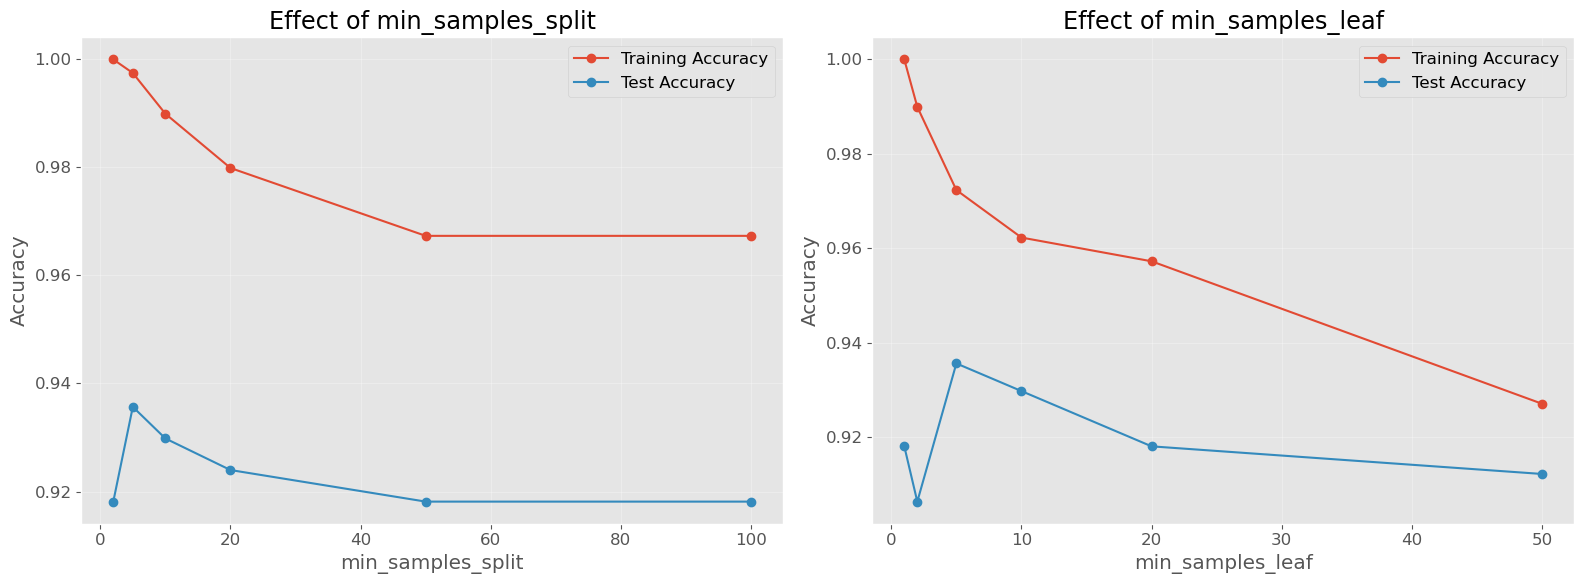

In [23]:
# Visualize the results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# min_samples_split plot
axes[0].plot(min_samples_splits, train_scores_mss, 'o-', label='Training Accuracy')
axes[0].plot(min_samples_splits, test_scores_mss, 'o-', label='Test Accuracy')
axes[0].set_xlabel('min_samples_split')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Effect of min_samples_split')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# min_samples_leaf plot
axes[1].plot(min_samples_leaves, train_scores_msl, 'o-', label='Training Accuracy')
axes[1].plot(min_samples_leaves, test_scores_msl, 'o-', label='Test Accuracy')
axes[1].set_xlabel('min_samples_leaf')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Effect of min_samples_leaf')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
# Find optimal values
best_mss = min_samples_splits[np.argmax(test_scores_mss)]
best_msl = min_samples_leaves[np.argmax(test_scores_msl)]

print(f"\nBest min_samples_split: {best_mss}")
print(f"Test accuracy with best min_samples_split: {max(test_scores_mss):.4f}")
print(f"\nBest min_samples_leaf: {best_msl}")
print(f"Test accuracy with best min_samples_leaf: {max(test_scores_msl):.4f}")


Best min_samples_split: 5
Test accuracy with best min_samples_split: 0.9357

Best min_samples_leaf: 5
Test accuracy with best min_samples_leaf: 0.9357


### Cost-Complexity Pruning (ccp_alpha)

In [25]:
# Use cost-complexity pruning to find optimal alpha
path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(
    X_train_scaled, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

# Remove the largest alpha that produces empty tree
if len(ccp_alphas) > 0:
    ccp_alphas = ccp_alphas[:-1]

# Train models with different alphas
train_scores_ccp = []
test_scores_ccp = []
node_counts = []
depth_counts = []

for alpha in ccp_alphas:
    dt = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    dt.fit(X_train_scaled, y_train)
    
    # Calculate accuracies
    train_acc = accuracy_score(y_train, dt.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, dt.predict(X_test_scaled))
    
    train_scores_ccp.append(train_acc)
    test_scores_ccp.append(test_acc)
    node_counts.append(dt.tree_.node_count)
    depth_counts.append(dt.get_depth())

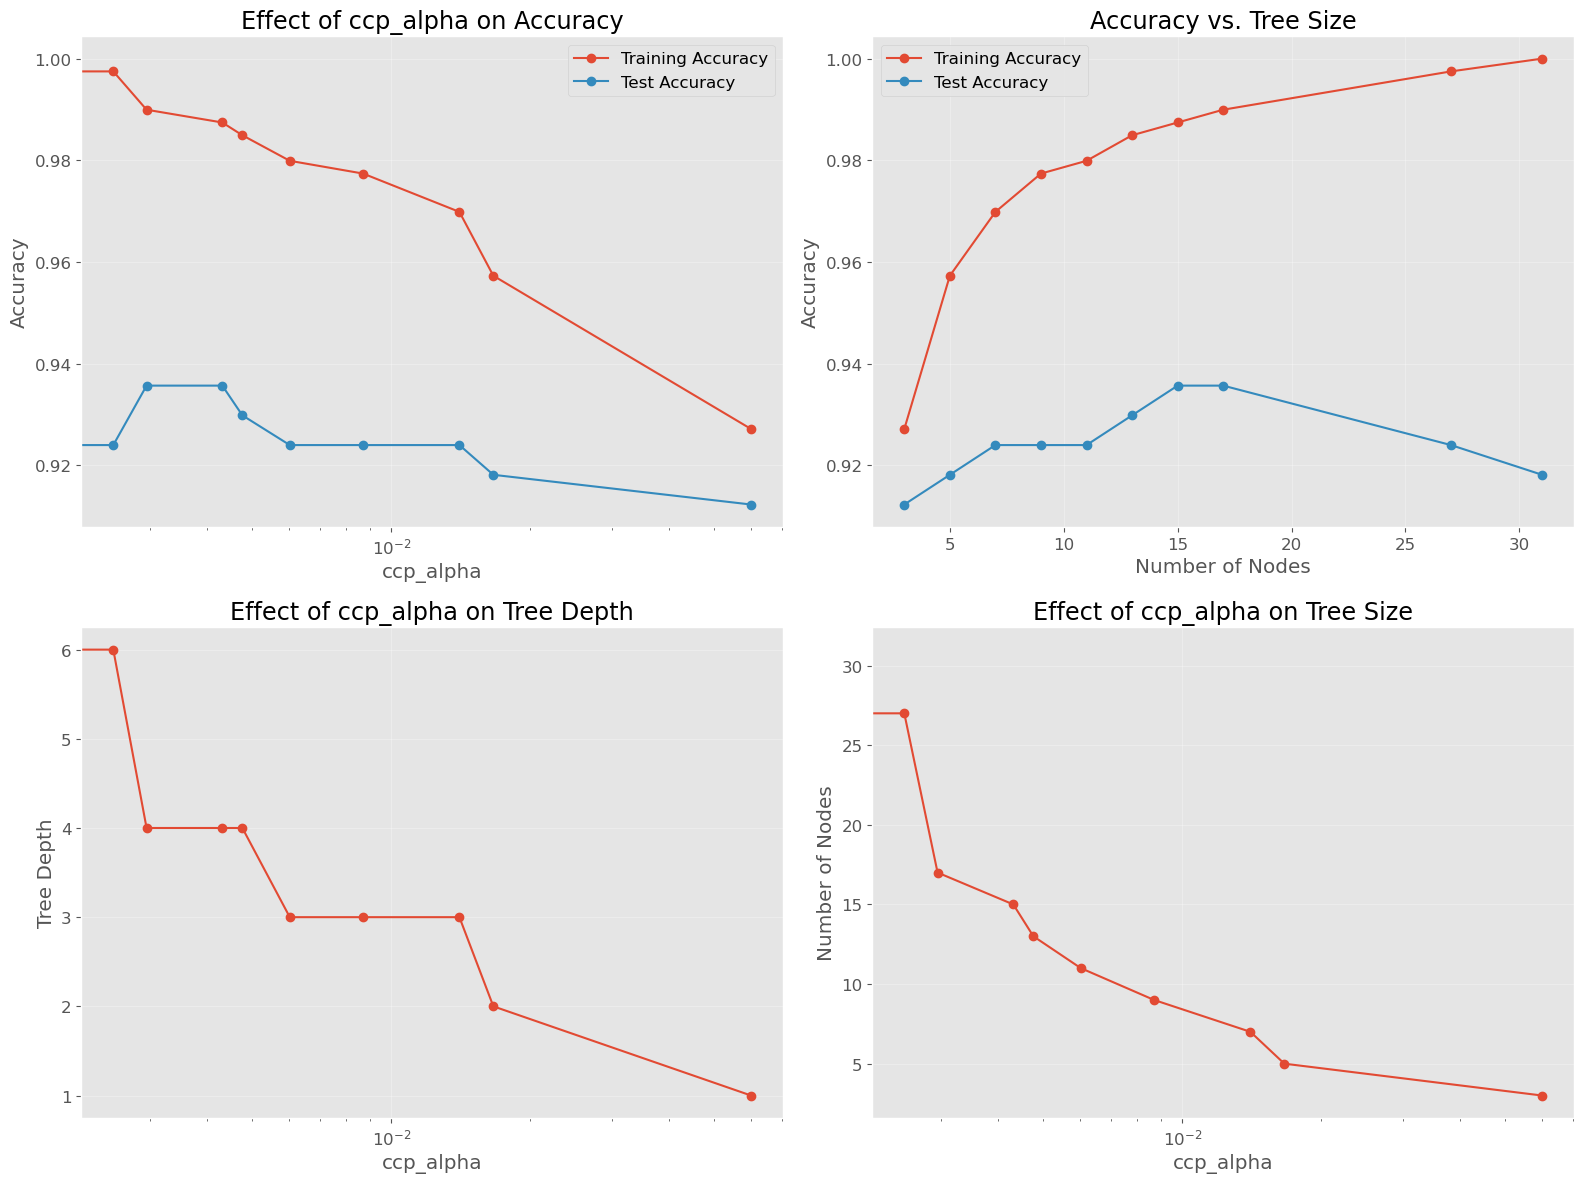

In [26]:
# Plot results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Alphas vs. accuracy
axes[0, 0].plot(ccp_alphas, train_scores_ccp, 'o-', label='Training Accuracy')
axes[0, 0].plot(ccp_alphas, test_scores_ccp, 'o-', label='Test Accuracy')
axes[0, 0].set_xlabel('ccp_alpha')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('Effect of ccp_alpha on Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xscale('log')

# Nodes vs. accuracy
axes[0, 1].plot(node_counts, train_scores_ccp, 'o-', label='Training Accuracy')
axes[0, 1].plot(node_counts, test_scores_ccp, 'o-', label='Test Accuracy')
axes[0, 1].set_xlabel('Number of Nodes')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Accuracy vs. Tree Size')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Alphas vs. tree depth
axes[1, 0].plot(ccp_alphas, depth_counts, 'o-')
axes[1, 0].set_xlabel('ccp_alpha')
axes[1, 0].set_ylabel('Tree Depth')
axes[1, 0].set_title('Effect of ccp_alpha on Tree Depth')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xscale('log')

# Alphas vs. node count
axes[1, 1].plot(ccp_alphas, node_counts, 'o-')
axes[1, 1].set_xlabel('ccp_alpha')
axes[1, 1].set_ylabel('Number of Nodes')
axes[1, 1].set_title('Effect of ccp_alpha on Tree Size')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xscale('log')

plt.tight_layout()
plt.show()

In [27]:
# Find optimal alpha
best_alpha_idx = np.argmax(test_scores_ccp)
best_alpha = ccp_alphas[best_alpha_idx]

print(f"Best ccp_alpha: {best_alpha:.6f}")
print(f"Test accuracy with best alpha: {test_scores_ccp[best_alpha_idx]:.4f}")
print(f"Tree depth with best alpha: {depth_counts[best_alpha_idx]}")
print(f"Number of nodes with best alpha: {node_counts[best_alpha_idx]}")

Best ccp_alpha: 0.002953
Test accuracy with best alpha: 0.9357
Tree depth with best alpha: 4
Number of nodes with best alpha: 17


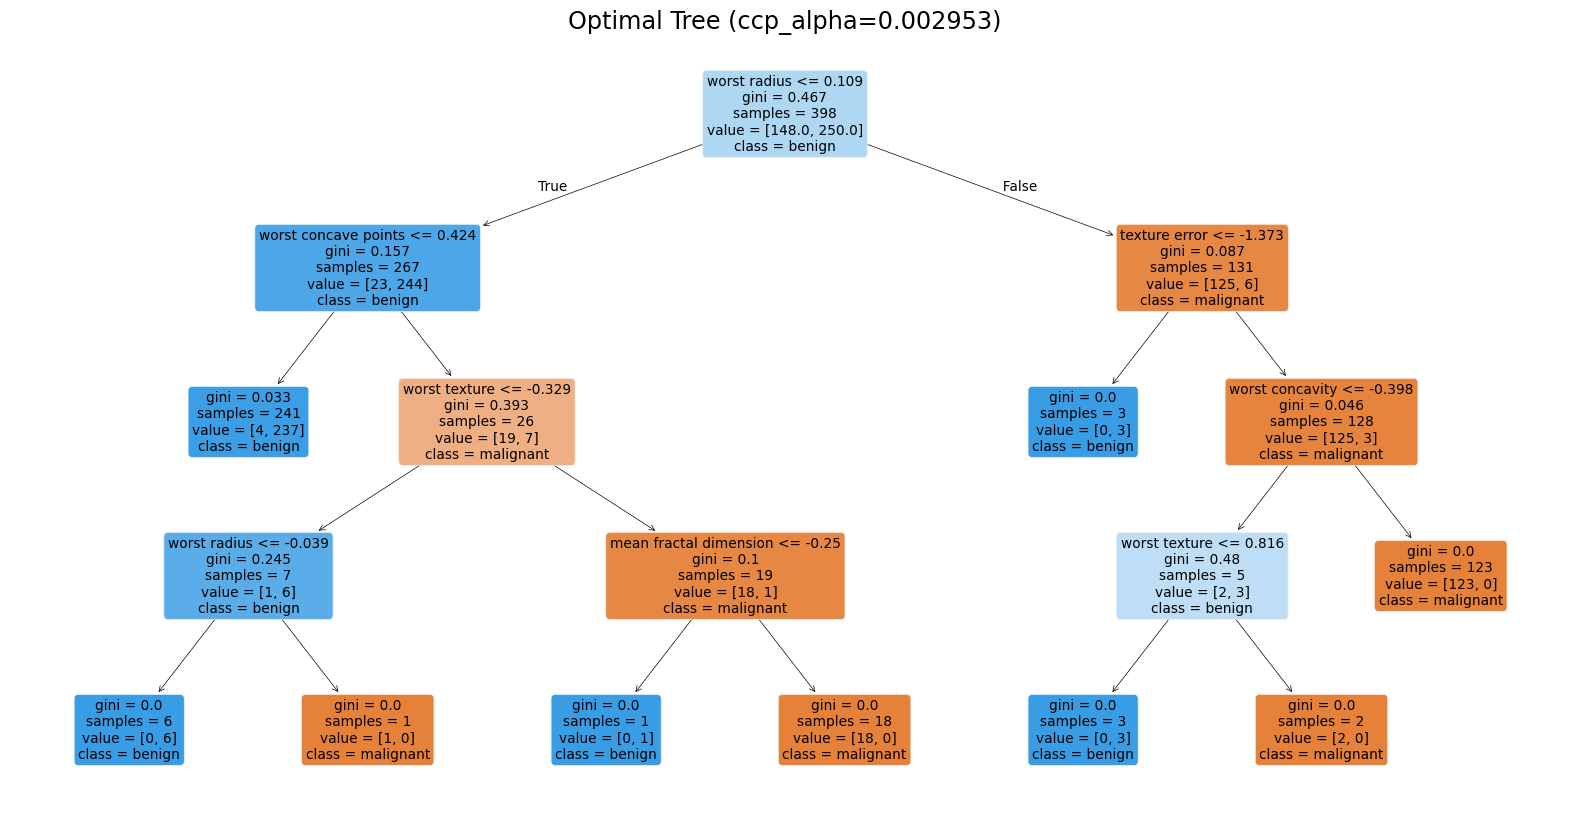

In [28]:
# Train and visualize the optimal tree
best_tree = DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=42)
best_tree.fit(X_train_scaled, y_train)

plt.figure(figsize=(20, 10))
plot_tree(best_tree, 
          filled=True,
          rounded=True,
          feature_names=feature_names,
          class_names=target_names)
plt.title(f"Optimal Tree (ccp_alpha={best_alpha:.6f})")
plt.show()

### Visualizing Performance vs. Complexity

Let's create a learning curve to better understand how model performance varies with training set size:

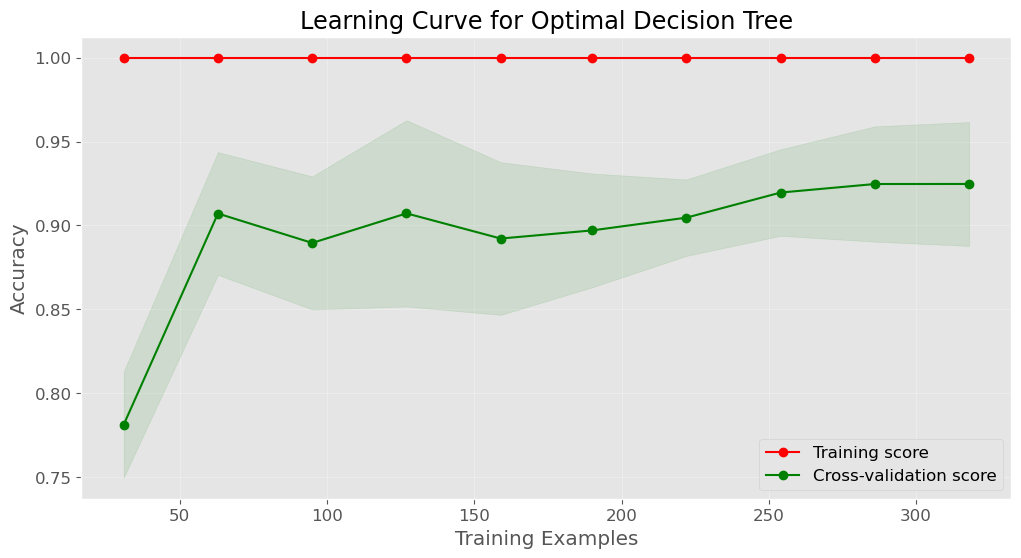

In [29]:
# Generate learning curve for our best model
best_tree = DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=42)

train_sizes, train_scores, test_scores = learning_curve(
    best_tree, X_train_scaled, y_train, 
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, scoring='accuracy')

# Calculate mean and standard deviation
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot learning curve
plt.figure(figsize=(12, 6))
plt.plot(train_sizes, train_mean, 'o-', color='r', label='Training score')
plt.plot(train_sizes, test_mean, 'o-', color='g', label='Cross-validation score')

# Add shaded regions for standard deviation
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')

plt.xlabel('Training Examples')
plt.ylabel('Accuracy')
plt.title('Learning Curve for Optimal Decision Tree')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

### Knowledge Check: Addressing Overfitting
1. Based on our experiments, what `max_depth` provides the best test accuracy, and why might an overly deep tree perform worse?
2. How do the `min_samples_split` and `min_samples_leaf` parameters help control overfitting?
3. What role does `ccp_alpha` play in controlling tree complexity, and how is it different from pre-pruning methods?
4. What does the learning curve tell us about the model's ability to learn from additional data?
5. If you had to choose just one hyperparameter to tune for a decision tree, which would you choose and why?

## Handling Categorical Features

While the Breast Cancer dataset doesn't have categorical features, let's create a synthetic dataset with categorical features to demonstrate how to handle them with decision trees.

In [30]:
# Create a synthetic dataset with categorical features
np.random.seed(42)
n_samples = 500

# Create categorical features
education_levels = ['High School', 'Bachelor', 'Master', 'PhD']
education = np.random.choice(education_levels, size=n_samples)

cities = ['New York', 'Los Angeles', 'Chicago', 'Houston', 'Phoenix']
city = np.random.choice(cities, size=n_samples)

# Create numerical features
age = np.random.normal(35, 10, size=n_samples).astype(int)
experience = np.random.normal(10, 5, size=n_samples).astype(int)
experience = np.maximum(0, experience)  # Ensure non-negative

# Create target (salary) based on features with some noise
base_salary = 30000
education_effect = {'High School': 0, 'Bachelor': 15000, 'Master': 25000, 'PhD': 40000}
city_effect = {'New York': 15000, 'Los Angeles': 12000, 'Chicago': 8000, 
               'Houston': 5000, 'Phoenix': 3000}

salary = base_salary + np.array([education_effect[e] for e in education]) + \
         np.array([city_effect[c] for c in city]) + \
         1000 * age + 2000 * experience + \
         np.random.normal(0, 10000, size=n_samples)

# Convert to classification problem: High vs Low salary
median_salary = np.median(salary)
salary_class = (salary > median_salary).astype(int)

# Create a DataFrame
data = pd.DataFrame({
    'education': education,
    'city': city,
    'age': age,
    'experience': experience,
    'salary_class': salary_class
})

print("Synthetic dataset with categorical features:")
print(data.head())

Synthetic dataset with categorical features:
     education         city  age  experience  salary_class
0       Master      Phoenix   26          22             1
1          PhD      Phoenix   25           9             1
2  High School     New York   33          12             0
3       Master      Chicago   34          18             1
4       Master  Los Angeles   24           5             1


### One-Hot Encoding

In [31]:
# Split the data
X_cat = data.drop('salary_class', axis=1)
y_cat = data['salary_class']

X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X_cat, y_cat, test_size=0.3, random_state=42)

# Create a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', ['age', 'experience']),
        ('cat', OneHotEncoder(drop='first'), ['education', 'city'])
    ])

# Create a pipeline with preprocessing and model
onehot_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Train and evaluate
onehot_pipeline.fit(X_train_cat, y_train_cat)
y_pred_onehot = onehot_pipeline.predict(X_test_cat)

print("\nOneHot Encoding - Decision Tree Performance:")
print(f"Accuracy: {accuracy_score(y_test_cat, y_pred_onehot):.4f}")
print(classification_report(y_test_cat, y_pred_onehot))

# Extract the trained classifier
tree_onehot = onehot_pipeline.named_steps['classifier']

# Get feature names after one-hot encoding
ohe = preprocessor.named_transformers_['cat']
cat_feature_names = ohe.get_feature_names_out(['education', 'city']).tolist()
feature_names_all = ['age', 'experience'] + cat_feature_names

# Print feature importances
importances = tree_onehot.feature_importances_
indices = np.argsort(importances)[::-1]

print("\nFeature importances with one-hot encoding:")
for i in range(len(importances)):
    if importances[indices[i]] > 0.01:  # Only show important features
        print(f"{feature_names_all[indices[i]]}: {importances[indices[i]]:.4f}")


OneHot Encoding - Decision Tree Performance:
Accuracy: 0.7800
              precision    recall  f1-score   support

           0       0.82      0.79      0.80        85
           1       0.74      0.77      0.75        65

    accuracy                           0.78       150
   macro avg       0.78      0.78      0.78       150
weighted avg       0.78      0.78      0.78       150


Feature importances with one-hot encoding:
age: 0.2952
education_PhD: 0.2308
experience: 0.2056
education_High School: 0.0911
city_Houston: 0.0614
education_Master: 0.0523
city_New York: 0.0287
city_Los Angeles: 0.0178
city_Phoenix: 0.0171


### Ordinal Encoding

In [32]:
# Create an ordinal encoder for education (has a natural order)
education_categories = ['High School', 'Bachelor', 'Master', 'PhD']
education_encoder = OrdinalEncoder(categories=[education_categories])

# For city, we'll still use one-hot encoding as it has no natural order
preprocessor_ordinal = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', ['age', 'experience']),
        ('edu', education_encoder, ['education']),
        ('city', OneHotEncoder(drop='first'), ['city'])
    ])

# Create a pipeline with preprocessing and model
ordinal_pipeline = Pipeline([
    ('preprocessor', preprocessor_ordinal),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Train and evaluate
ordinal_pipeline.fit(X_train_cat, y_train_cat)
y_pred_ordinal = ordinal_pipeline.predict(X_test_cat)

print("\nOrdinal Encoding - Decision Tree Performance:")
print(f"Accuracy: {accuracy_score(y_test_cat, y_pred_ordinal):.4f}")
print(classification_report(y_test_cat, y_pred_ordinal))

# Extract the trained classifier
tree_ordinal = ordinal_pipeline.named_steps['classifier']

# Get feature names after encoding
city_ohe = preprocessor_ordinal.named_transformers_['city']
city_feature_names = city_ohe.get_feature_names_out(['city']).tolist()
feature_names_ordinal = ['age', 'experience', 'education_ordinal'] + city_feature_names

# Print feature importances
importances = tree_ordinal.feature_importances_
indices = np.argsort(importances)[::-1]

print("\nFeature importances with ordinal encoding:")
for i in range(len(importances)):
    if importances[indices[i]] > 0.01:  # Only show important features
        print(f"{feature_names_ordinal[indices[i]]}: {importances[indices[i]]:.4f}")


Ordinal Encoding - Decision Tree Performance:
Accuracy: 0.7400
              precision    recall  f1-score   support

           0       0.78      0.75      0.77        85
           1       0.69      0.72      0.71        65

    accuracy                           0.74       150
   macro avg       0.74      0.74      0.74       150
weighted avg       0.74      0.74      0.74       150


Feature importances with ordinal encoding:
education_ordinal: 0.3974
age: 0.2797
experience: 0.2093
city_Houston: 0.0348
city_Phoenix: 0.0294
city_New York: 0.0269
city_Los Angeles: 0.0223


### Impact on Tree Performance

In [33]:
# Compare the performance of the two approaches
print("\nComparison of Encoding Techniques:")
print(f"OneHot Encoding Accuracy: {accuracy_score(y_test_cat, y_pred_onehot):.4f}")
print(f"Ordinal Encoding Accuracy: {accuracy_score(y_test_cat, y_pred_ordinal):.4f}")

# Visualize the trees (if not too large)
if tree_onehot.get_depth() <= 5:
    plt.figure(figsize=(20, 10))
    plot_tree(tree_onehot, 
              filled=True,
              rounded=True,
              feature_names=feature_names_all,
              class_names=['Low Salary', 'High Salary'])
    plt.title("Decision Tree with OneHot Encoding")
    plt.show()
else:
    print(f"Tree with OneHot encoding too large to visualize: depth = {tree_onehot.get_depth()}")

if tree_ordinal.get_depth() <= 5:
    plt.figure(figsize=(20, 10))
    plot_tree(tree_ordinal, 
              filled=True,
              rounded=True,
              feature_names=feature_names_ordinal,
              class_names=['Low Salary', 'High Salary'])
    plt.title("Decision Tree with Ordinal Encoding")
    plt.show()
else:
    print(f"Tree with Ordinal encoding too large to visualize: depth = {tree_ordinal.get_depth()}")


Comparison of Encoding Techniques:
OneHot Encoding Accuracy: 0.7800
Ordinal Encoding Accuracy: 0.7400
Tree with OneHot encoding too large to visualize: depth = 12
Tree with Ordinal encoding too large to visualize: depth = 12


### Knowledge Check: Handling Categorical Features
1. What are the key differences between one-hot encoding and ordinal encoding for categorical data?
2. When would you use ordinal encoding instead of one-hot encoding?
3. How do encodings affect the feature importances in a decision tree?
4. What potential issues might arise with high-cardinality categorical features (features with many unique values)?
5. Why is preprocessing categorical features important even though decision trees can sometimes handle categorical data directly?

## Model Interpretation

Let's return to our Breast Cancer dataset and focus on interpreting the model.

### Feature Importance Analysis


--- Pruned Decision Tree Performance ---
Test accuracy: 0.9240


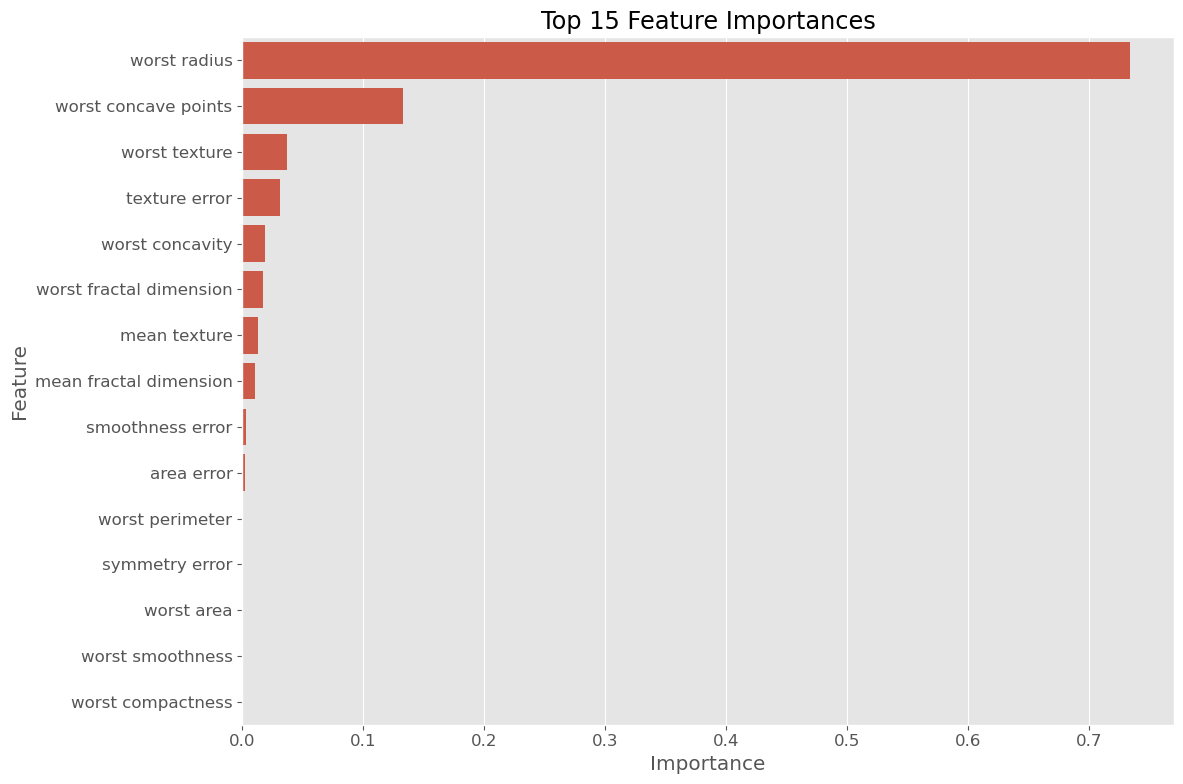


Top 10 most important features:
                    Feature  Importance
20             worst radius    0.733864
27     worst concave points    0.132649
21            worst texture    0.036691
11            texture error    0.030980
26          worst concavity    0.019168
29  worst fractal dimension    0.016887
1              mean texture    0.013298
9    mean fractal dimension    0.010499
14         smoothness error    0.003377
13               area error    0.002586


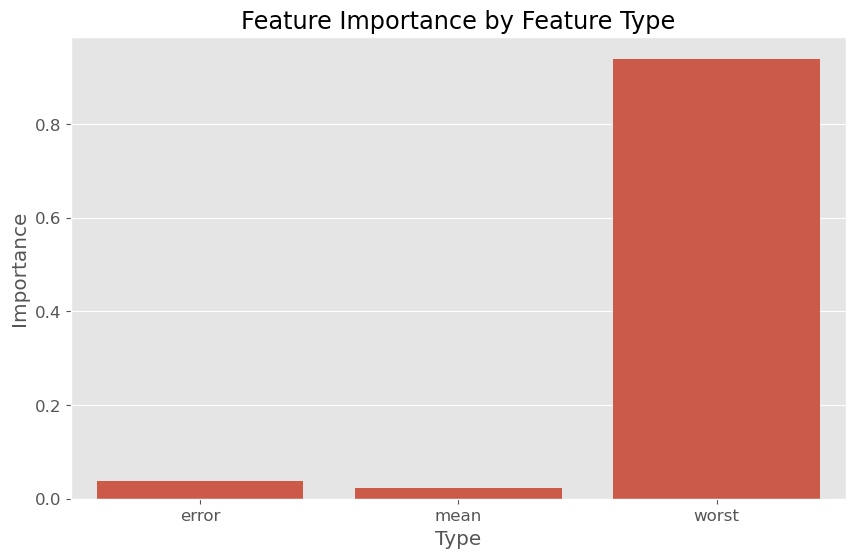


Feature importance by type:
    Type  Importance
0  error    0.036943
1   mean    0.023797
2  worst    0.939260


In [35]:
# Train a pruned decision tree to avoid overfitting
dt_pruned = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_pruned.fit(X_train_scaled, y_train)

# Display model performance
y_pred_pruned = dt_pruned.predict(X_test_scaled)
print("\n--- Pruned Decision Tree Performance ---")
print(f"Test accuracy: {accuracy_score(y_test, y_pred_pruned):.4f}")

# Calculate and visualize feature importances
importances = dt_pruned.feature_importances_
indices = np.argsort(importances)[::-1]

# Create a DataFrame of feature importances for better analysis
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})
importance_df = importance_df.sort_values('Importance', ascending=False)

# Visualize top features
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15))
plt.title('Top 15 Feature Importances')
plt.tight_layout()
plt.show()

# Print top 10 feature importances
print("\nTop 10 most important features:")
print(importance_df.head(10))

# Group feature importances by feature type (mean, error, worst)
feature_types = []
for feature in feature_names:
    if 'mean' in feature:
        feature_types.append('mean')
    elif 'error' in feature:
        feature_types.append('error')
    elif 'worst' in feature:
        feature_types.append('worst')
    else:
        feature_types.append('other')

importance_df['Type'] = [feature_types[list(feature_names).index(feature)] 
                        for feature in importance_df['Feature']]

# Calculate aggregate importance by type
importance_by_type = importance_df.groupby('Type')['Importance'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Type', y='Importance', data=importance_by_type)
plt.title('Feature Importance by Feature Type')
plt.show()

print("\nFeature importance by type:")
print(importance_by_type)

### Decision Boundaries Visualization (2D example)

For better visualization, let's reduce our dataset to 2 dimensions using PCA and visualize the decision boundaries:


Decision Tree with top 2 features - Test accuracy: 0.9181


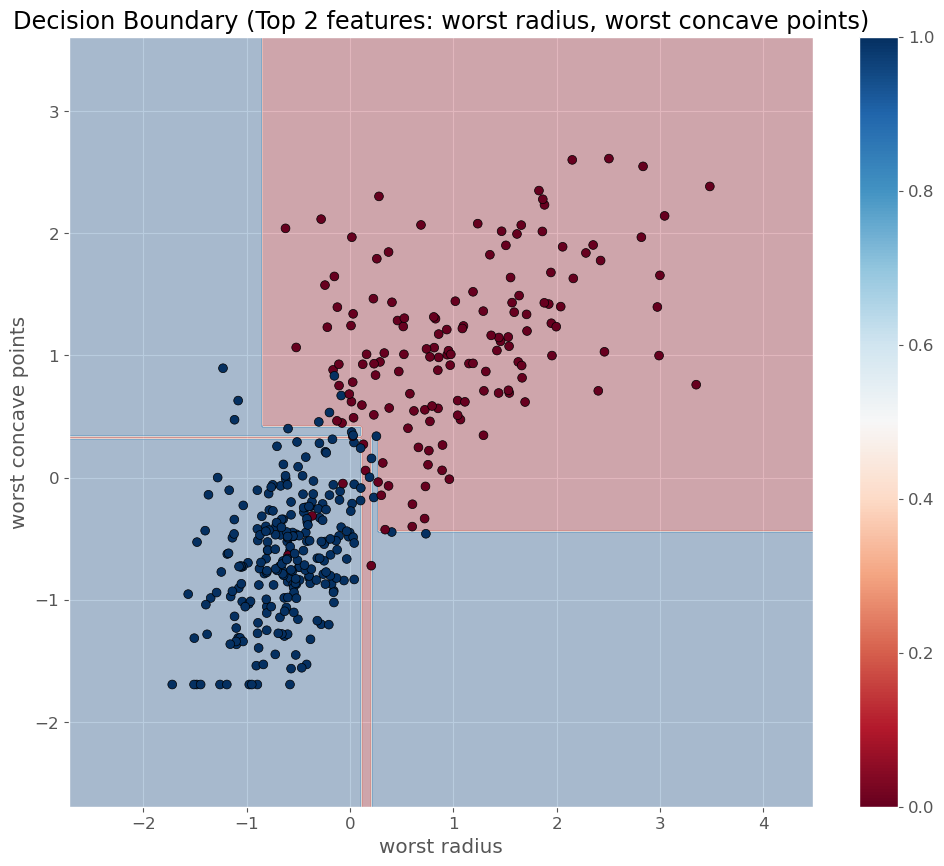

Decision Tree with PCA features - Test accuracy: 0.9708


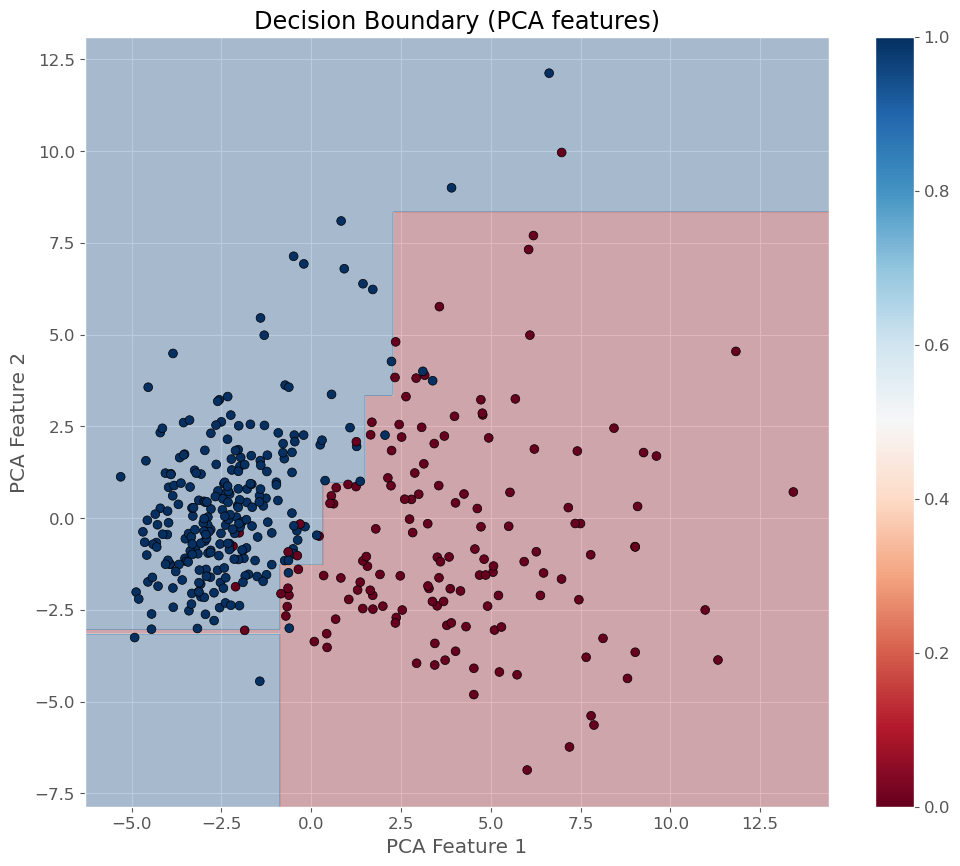

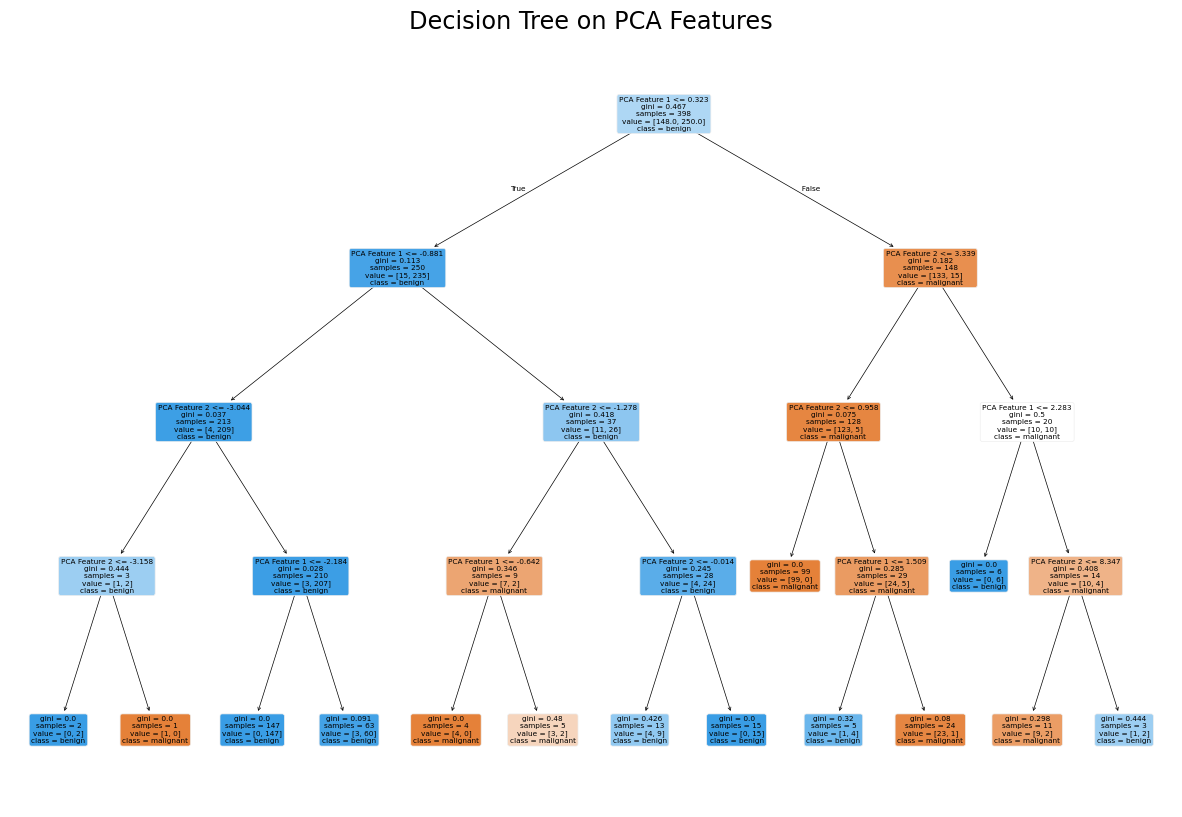

In [36]:
# Select two most important features for visualization
top_features = importance_df['Feature'].iloc[:2].values
X_top_features = X_train_scaled[:, np.array([list(feature_names).index(f) for f in top_features])]
X_test_top = X_test_scaled[:, np.array([list(feature_names).index(f) for f in top_features])]

# Train a decision tree on just these features
dt_2d = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_2d.fit(X_top_features, y_train)

# Evaluate
y_pred_2d = dt_2d.predict(X_test_top)
print(f"\nDecision Tree with top 2 features - Test accuracy: {accuracy_score(y_test, y_pred_2d):.4f}")

# Create mesh grid for visualization
h = 0.02  # Step size
x_min, x_max = X_top_features[:, 0].min() - 1, X_top_features[:, 0].max() + 1
y_min, y_max = X_top_features[:, 1].min() - 1, X_top_features[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Make predictions on the mesh grid
Z = dt_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Visualize decision boundary
plt.figure(figsize=(12, 10))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdBu)
plt.scatter(X_top_features[:, 0], X_top_features[:, 1], c=y_train, 
           cmap=plt.cm.RdBu, edgecolor='k', s=40)
plt.title(f'Decision Boundary (Top 2 features: {top_features[0]}, {top_features[1]})')
plt.xlabel(top_features[0])
plt.ylabel(top_features[1])
plt.colorbar()
plt.show()

# Also train a tree with PCA features
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Train decision tree on PCA features
dt_pca = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_pca.fit(X_train_pca, y_train)

# Evaluate
y_pred_pca = dt_pca.predict(X_test_pca)
print(f"Decision Tree with PCA features - Test accuracy: {accuracy_score(y_test, y_pred_pca):.4f}")

# Create mesh grid for visualization
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Make predictions on the mesh grid
Z = dt_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Visualize decision boundary
plt.figure(figsize=(12, 10))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdBu)
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, 
           cmap=plt.cm.RdBu, edgecolor='k', s=40)
plt.title('Decision Boundary (PCA features)')
plt.xlabel('PCA Feature 1')
plt.ylabel('PCA Feature 2')
plt.colorbar()
plt.show()

# Visualize the PCA-based tree
plt.figure(figsize=(15, 10))
plot_tree(dt_pca, 
          filled=True,
          rounded=True,
          feature_names=['PCA Feature 1', 'PCA Feature 2'],
          class_names=target_names)
plt.title("Decision Tree on PCA Features")
plt.show()

### Interpreting Decision Paths

Let's examine how our model makes predictions for specific samples:

In [37]:
# Create a function to explain predictions
def explain_prediction(model, sample, feature_names, class_names):
    """Explain how a decision tree makes a prediction for a single sample."""
    # Get the decision path
    decision_path = model.decision_path([sample])
    node_indicator = decision_path.toarray()[0]
    
    # Get tree structure
    tree = model.tree_
    feature = tree.feature
    threshold = tree.threshold
    
    # Get leaf node containing the sample
    leaf_id = -1
    for node_id in range(tree.node_count):
        # If this is a leaf node
        if tree.children_left[node_id] == tree.children_right[node_id]:
            if node_indicator[node_id] == 1:
                leaf_id = node_id
                break
    
    # Traverse decision path
    path = []
    node_id = 0  # Start at root
    
    while node_id != leaf_id:
        # If sample goes through this node
        if node_indicator[node_id] == 1:
            # Get feature and threshold at this node
            feature_idx = feature[node_id]
            threshold_value = threshold[node_id]
            
            # Get the feature name
            feature_name = feature_names[feature_idx]
            
            # Get sample value
            sample_value = sample[feature_idx]
            
            # Determine which direction sample goes
            if sample_value <= threshold_value:
                decision = f"{feature_name} <= {threshold_value:.4f} (Sample value: {sample_value:.4f})"
                node_id = tree.children_left[node_id]
            else:
                decision = f"{feature_name} > {threshold_value:.4f} (Sample value: {sample_value:.4f})"
                node_id = tree.children_right[node_id]
            
            path.append(decision)
    
    # Get prediction
    prediction = model.predict([sample])[0]
    pred_proba = model.predict_proba([sample])[0]
    
    return {
        'path': path,
        'prediction': class_names[prediction],
        'probabilities': {class_names[i]: prob for i, prob in enumerate(pred_proba)}
    }

# Select a few samples to explain
samples_to_explain = [
    X_test_scaled[0],  # First test sample
    X_test_scaled[10],  # Another test sample
    X_test_scaled[20]   # Yet another test sample
]

# Explain predictions
for i, sample in enumerate(samples_to_explain):
    print(f"\n--- Sample {i+1} Explanation ---")
    explanation = explain_prediction(dt_pruned, sample, feature_names, target_names)
    
    print(f"Prediction: {explanation['prediction']}")
    print(f"Probabilities: {explanation['probabilities']}")
    print("Decision path:")
    for j, decision in enumerate(explanation['path']):
        print(f"  {j+1}. {decision}")
    
    # Show true label
    true_label = target_names[y_test[i if i == 0 else (10 if i == 1 else 20)]]
    print(f"True label: {true_label}")


--- Sample 1 Explanation ---
Prediction: malignant
Probabilities: {'malignant': 1.0, 'benign': 0.0}
Decision path:
  1. worst radius <= 0.1091 (Sample value: -0.2553)
  2. worst concave points > 0.4239 (Sample value: 1.5720)
  3. worst texture > -0.3285 (Sample value: 0.9800)
  4. mean fractal dimension > -0.2505 (Sample value: 1.9317)
True label: malignant

--- Sample 2 Explanation ---
Prediction: benign
Probabilities: {'malignant': 0.004484304932735426, 'benign': 0.9955156950672646}
Decision path:
  1. worst radius <= 0.1091 (Sample value: -0.8561)
  2. worst concave points <= 0.4239 (Sample value: -1.1129)
  3. smoothness error > -1.2168 (Sample value: -0.4753)
  4. area error <= -0.0811 (Sample value: -0.2736)
True label: benign

--- Sample 3 Explanation ---
Prediction: benign
Probabilities: {'malignant': 0.004484304932735426, 'benign': 0.9955156950672646}
Decision path:
  1. worst radius <= 0.1091 (Sample value: -0.4266)
  2. worst concave points <= 0.4239 (Sample value: -0.8627)

### Knowledge Check: Model Interpretation
1. Based on feature importance, which characteristics of cell nuclei appear to be most predictive of malignancy?
2. How does the decision boundary visualization help in understanding the model's predictions?
3. Looking at the decision paths for the explained samples, what insights can you gather about how the model makes predictions?
4. How might feature importance help guide further data collection or research in breast cancer diagnosis?
5. Why might PCA features result in a different accuracy compared to using the most important original features?

## Comparing Different Criteria (Gini vs. Entropy)

Let's compare the performance and structure of trees built using different splitting criteria:


--- Comparing Gini vs. Entropy Criteria ---
Gini criterion - Test accuracy: 0.9240
Entropy criterion - Test accuracy: 0.9532

Gini tree - Depth: 4, Leaves: 12
Entropy tree - Depth: 4, Leaves: 11

Feature importance comparison (top differences):
                    Feature  Gini Importance  Entropy Importance  \
20             worst radius         0.733864            0.639298   
6            mean concavity         0.000000            0.055070   
27     worst concave points         0.132649            0.172634   
11            texture error         0.030980            0.000000   
26          worst concavity         0.019168            0.000000   
1              mean texture         0.013298            0.030838   
29  worst fractal dimension         0.016887            0.000000   
7       mean concave points         0.000000            0.013980   
12          perimeter error         0.000000            0.013702   
18           symmetry error         0.000000            0.013643   

    A

<Figure size 1200x800 with 0 Axes>

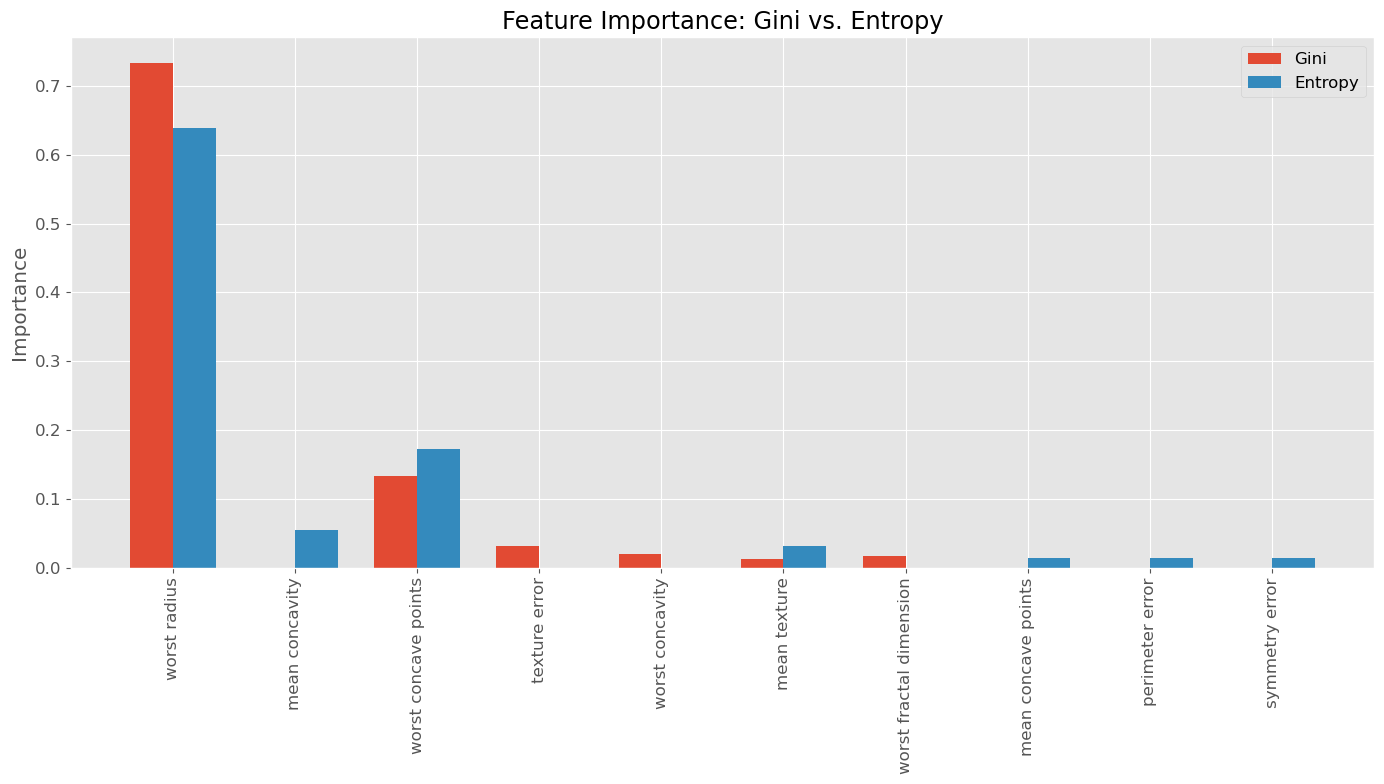

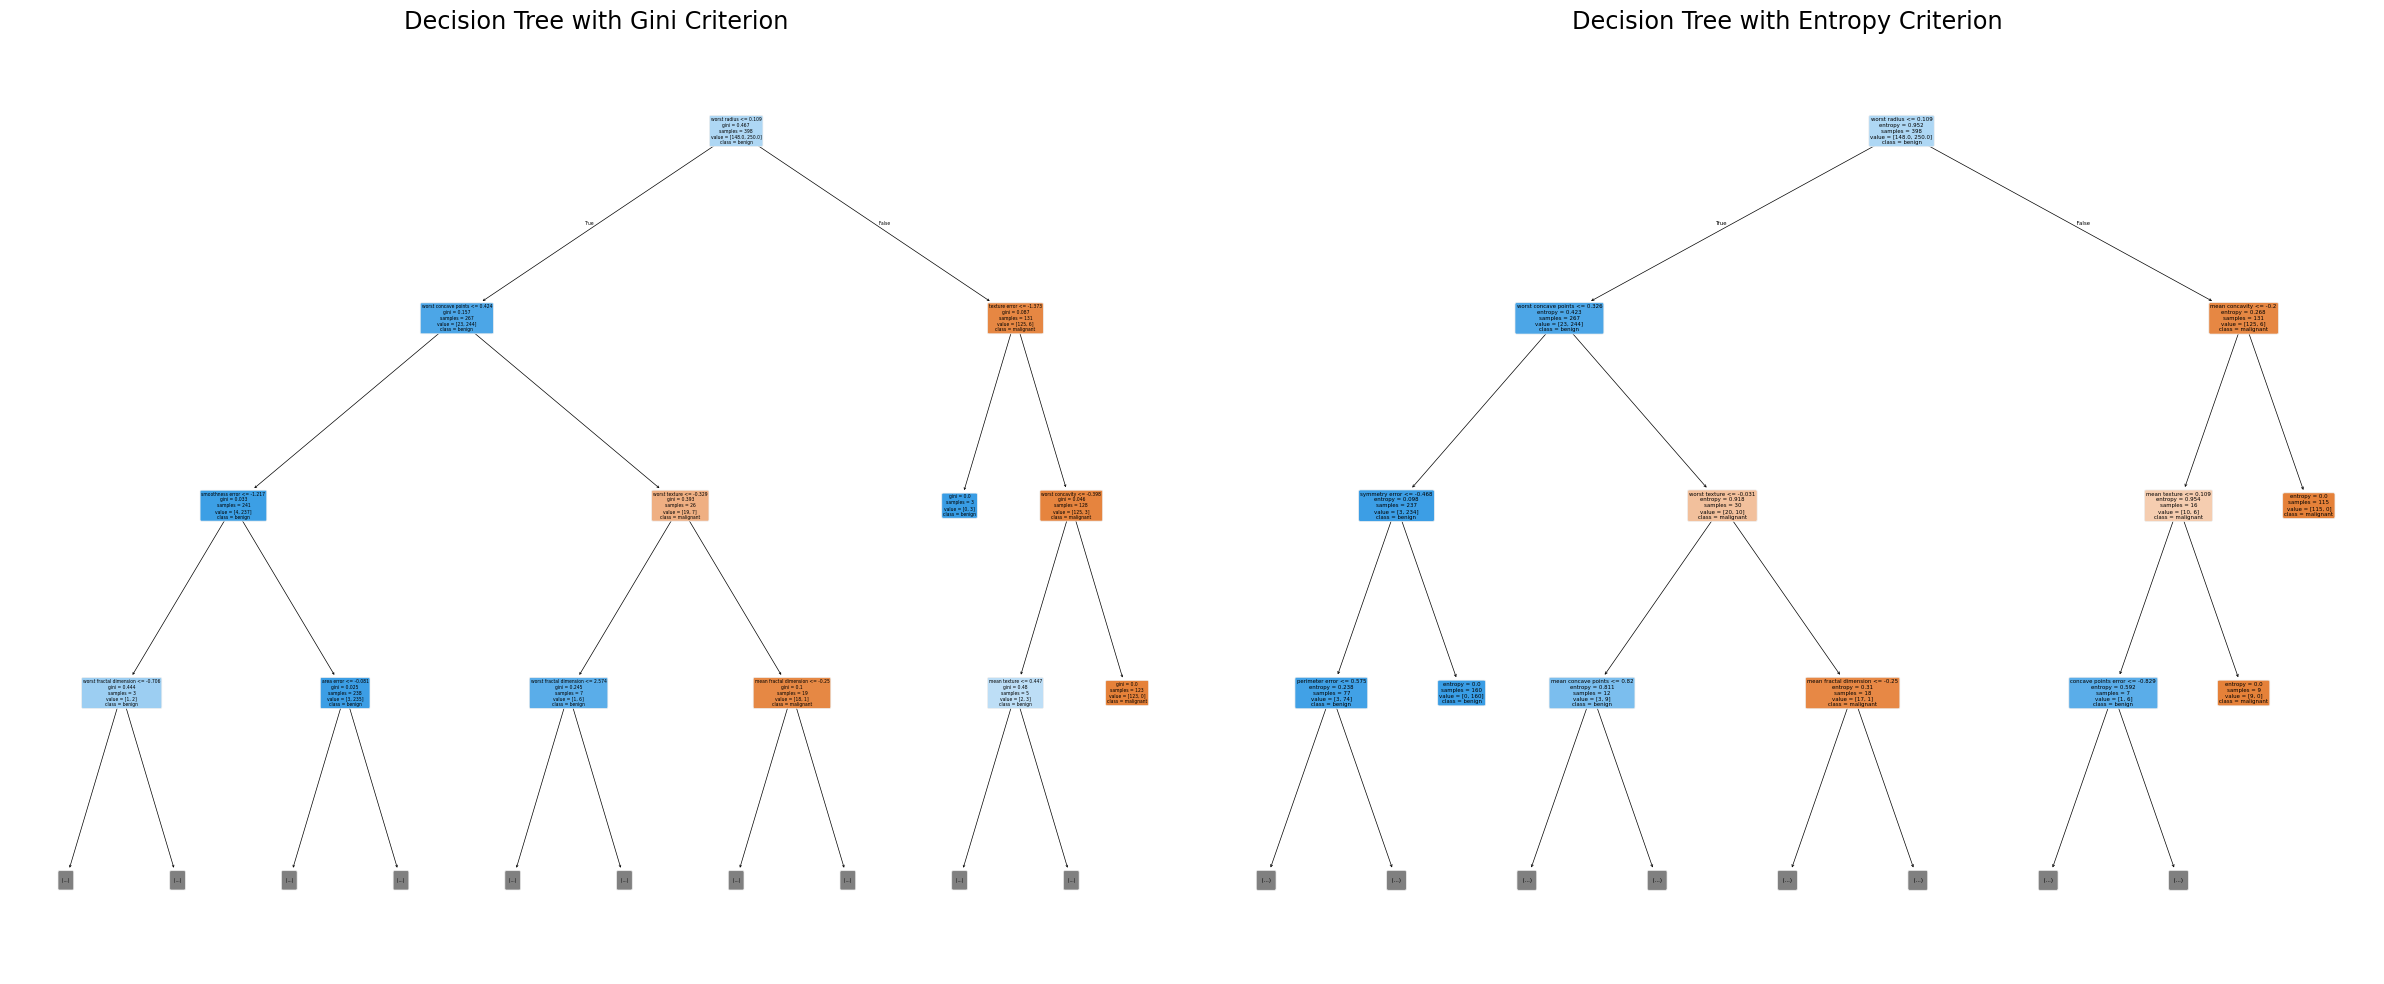

In [38]:
# Train trees with different criteria
gini_tree = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)
entropy_tree = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

gini_tree.fit(X_train_scaled, y_train)
entropy_tree.fit(X_train_scaled, y_train)

# Make predictions
y_pred_gini = gini_tree.predict(X_test_scaled)
y_pred_entropy = entropy_tree.predict(X_test_scaled)

# Evaluate performance
print("\n--- Comparing Gini vs. Entropy Criteria ---")
print(f"Gini criterion - Test accuracy: {accuracy_score(y_test, y_pred_gini):.4f}")
print(f"Entropy criterion - Test accuracy: {accuracy_score(y_test, y_pred_entropy):.4f}")

# Compare tree structures
print(f"\nGini tree - Depth: {gini_tree.get_depth()}, Leaves: {gini_tree.get_n_leaves()}")
print(f"Entropy tree - Depth: {entropy_tree.get_depth()}, Leaves: {entropy_tree.get_n_leaves()}")

# Compare feature importances
gini_importances = gini_tree.feature_importances_
entropy_importances = entropy_tree.feature_importances_

# Create a DataFrame for comparison
importance_comparison = pd.DataFrame({
    'Feature': feature_names,
    'Gini Importance': gini_importances,
    'Entropy Importance': entropy_importances
})
importance_comparison['Absolute Difference'] = abs(
    importance_comparison['Gini Importance'] - importance_comparison['Entropy Importance'])
importance_comparison = importance_comparison.sort_values('Absolute Difference', ascending=False)

print("\nFeature importance comparison (top differences):")
print(importance_comparison.head(10))

# Visualize the comparison
plt.figure(figsize=(12, 8))
top_features = importance_comparison.head(10)['Feature'].values
gini_values = [importance_comparison[importance_comparison['Feature'] == f]['Gini Importance'].values[0] 
               for f in top_features]
entropy_values = [importance_comparison[importance_comparison['Feature'] == f]['Entropy Importance'].values[0] 
                 for f in top_features]

x = np.arange(len(top_features))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 8))
ax.bar(x - width/2, gini_values, width, label='Gini')
ax.bar(x + width/2, entropy_values, width, label='Entropy')

ax.set_ylabel('Importance')
ax.set_title('Feature Importance: Gini vs. Entropy')
ax.set_xticks(x)
ax.set_xticklabels(top_features, rotation=90)
ax.legend()

plt.tight_layout()
plt.show()

# Visualize both trees side by side
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

plot_tree(gini_tree, 
          max_depth=3,  # Limit for visualization
          filled=True,
          rounded=True,
          feature_names=feature_names,
          class_names=target_names,
          ax=axes[0])
axes[0].set_title("Decision Tree with Gini Criterion")

plot_tree(entropy_tree, 
          max_depth=3,  # Limit for visualization
          filled=True,
          rounded=True,
          feature_names=feature_names,
          class_names=target_names,
          ax=axes[1])
axes[1].set_title("Decision Tree with Entropy Criterion")

plt.tight_layout()
plt.show()

### Knowledge Check: Comparing Criteria
1. What are the main differences between trees built using Gini vs. Entropy criteria?
2. Which criterion resulted in better performance in our case, and why might this be?
3. How do the feature importances differ between Gini and Entropy trees?
4. In what scenarios might you prefer one criterion over the other?
5. Why do decision trees in scikit-learn default to using the Gini criterion?

## Analysis of Misclassified Samples

Let's analyze the samples that our best model misclassifies:

In [39]:
# Use our best model (determined earlier)
best_tree = DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=42)
best_tree.fit(X_train_scaled, y_train)

# Make predictions
y_pred_best = best_tree.predict(X_test_scaled)
y_pred_proba = best_tree.predict_proba(X_test_scaled)[:, 1]  # Probability of positive class

# Identify misclassified samples
misclassified = X_test_scaled[y_test != y_pred_best]
misclassified_true = y_test[y_test != y_pred_best]
misclassified_pred = y_pred_best[y_test != y_pred_best]
misclassified_proba = y_pred_proba[y_test != y_pred_best]

print("\n--- Analysis of Misclassified Samples ---")
print(f"Number of misclassified samples: {len(misclassified)} out of {len(X_test_scaled)}")
print(f"Misclassification rate: {len(misclassified) / len(X_test_scaled):.4f}")


--- Analysis of Misclassified Samples ---
Number of misclassified samples: 11 out of 171
Misclassification rate: 0.0643


In [40]:
# Breakdown of misclassifications by class
fp = sum((y_test == 0) & (y_pred_best == 1))  # False positives
fn = sum((y_test == 1) & (y_pred_best == 0))  # False negatives

print(f"False positives (benign predicted as malignant): {fp}")
print(f"False negatives (malignant predicted as benign): {fn}")

False positives (benign predicted as malignant): 7
False negatives (malignant predicted as benign): 4


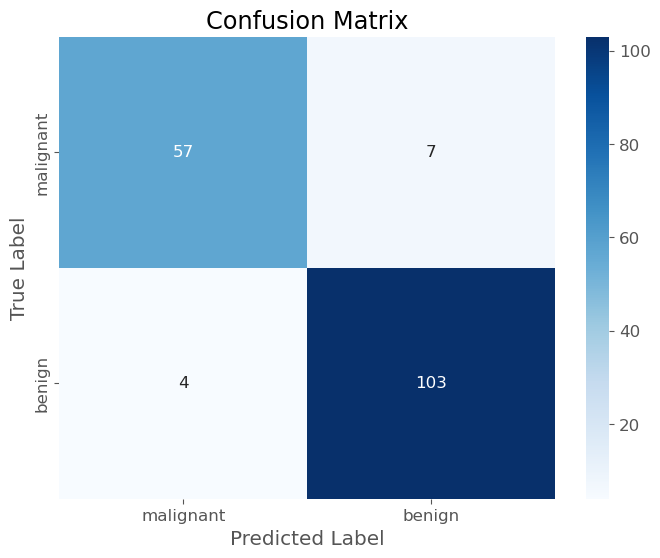

In [41]:
# Create a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

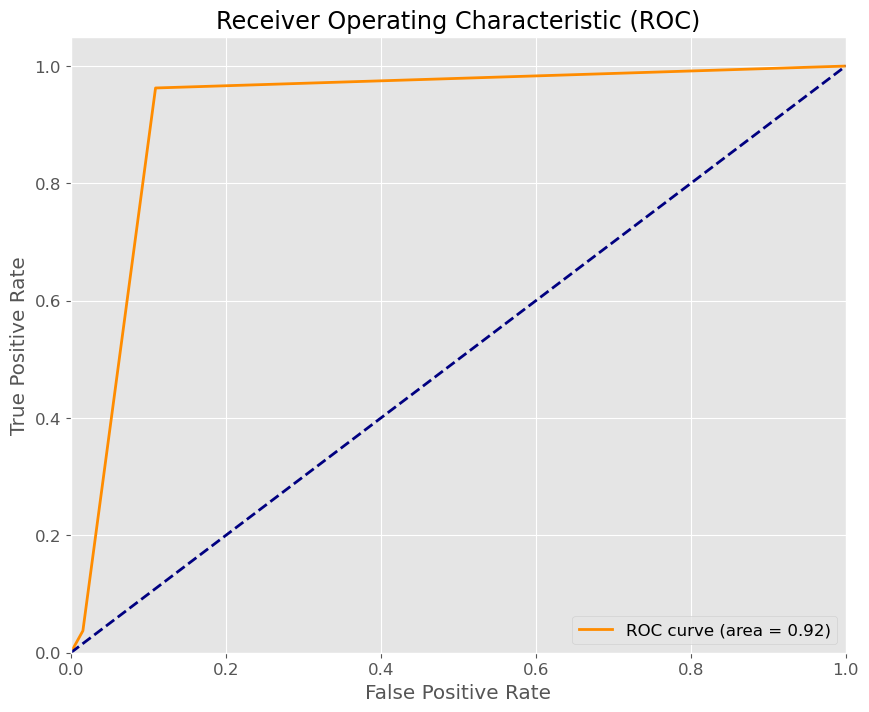

In [42]:
# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

In [43]:
# Analyze feature values of misclassified samples
if len(misclassified) > 0:
    # Convert back to original scale for interpretability
    misclassified_orig = scaler.inverse_transform(misclassified)
    X_test_orig = scaler.inverse_transform(X_test_scaled)
    
    # Calculate mean values for each feature by class in both correct and misclassified sets
    correctly_classified_benign = X_test_orig[(y_test == 0) & (y_pred_best == 0)]
    correctly_classified_malignant = X_test_orig[(y_test == 1) & (y_pred_best == 1)]
    
    misclassified_benign_as_malignant = X_test_orig[(y_test == 0) & (y_pred_best == 1)]
    misclassified_malignant_as_benign = X_test_orig[(y_test == 1) & (y_pred_best == 0)]
    
    # Calculate mean feature values for each group
    benign_mean = np.mean(correctly_classified_benign, axis=0)
    malignant_mean = np.mean(correctly_classified_malignant, axis=0)
    
    # Create a DataFrame for clear comparison
    comparison_data = []
    
    # Add correctly classified means
    for i, feature in enumerate(feature_names):
        comparison_data.append({
            'Feature': feature,
            'Benign (Correct)': benign_mean[i],
            'Malignant (Correct)': malignant_mean[i],
            'Difference': malignant_mean[i] - benign_mean[i]
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    comparison_df = comparison_df.sort_values('Difference', key=abs, ascending=False)
    
    print("\nTop discriminating features (based on correctly classified samples):")
    print(comparison_df.head(10))
    
    # If there are false positives (benign misclassified as malignant)
    if len(misclassified_benign_as_malignant) > 0:
        fp_mean = np.mean(misclassified_benign_as_malignant, axis=0)
        
        print("\nFalse Positives Analysis (Benign misclassified as Malignant):")
        for i, feature in enumerate(comparison_df['Feature'].iloc[:10]):  # Top 10 features
            idx = list(feature_names).index(feature)
            fp_value = fp_mean[idx]
            benign_value = benign_mean[idx]
            malignant_value = malignant_mean[idx]
            
            # Determine if the misclassified value is closer to its true class or predicted class
            closer_to = "true class (benign)" if abs(fp_value - benign_value) < abs(fp_value - malignant_value) else "predicted class (malignant)"
            
            print(f"{feature}:")
            print(f"  - Typical benign: {benign_value:.2f}")
            print(f"  - Typical malignant: {malignant_value:.2f}")
            print(f"  - Misclassified value: {fp_value:.2f} (closer to {closer_to})")
    
    # If there are false negatives (malignant misclassified as benign)
    if len(misclassified_malignant_as_benign) > 0:
        fn_mean = np.mean(misclassified_malignant_as_benign, axis=0)
        
        print("\nFalse Negatives Analysis (Malignant misclassified as Benign):")
        for i, feature in enumerate(comparison_df['Feature'].iloc[:10]):  # Top 10 features
            idx = list(feature_names).index(feature)
            fn_value = fn_mean[idx]
            benign_value = benign_mean[idx]
            malignant_value = malignant_mean[idx]
            
            # Determine if the misclassified value is closer to its true class or predicted class
            closer_to = "predicted class (benign)" if abs(fn_value - benign_value) < abs(fn_value - malignant_value) else "true class (malignant)"
            
            print(f"{feature}:")
            print(f"  - Typical benign: {benign_value:.2f}")
            print(f"  - Typical malignant: {malignant_value:.2f}")
            print(f"  - Misclassified value: {fn_value:.2f} (closer to {closer_to})")


Top discriminating features (based on correctly classified samples):
            Feature  Benign (Correct)  Malignant (Correct)  Difference
23       worst area       1497.789474           553.732039 -944.057435
3         mean area       1036.747368           460.505825 -576.241543
13       area error         92.101228            20.908592  -71.192636
22  worst perimeter        145.108772            86.718447  -58.390325
2    mean perimeter        118.681754            78.093883  -40.587871
20     worst radius         21.691930            13.328330   -8.363600
0       mean radius         17.923509            12.132505   -5.791004
21    worst texture         29.039825            23.300583   -5.739242
1      mean texture         21.580877            17.840971   -3.739906
12  perimeter error          5.125368             1.997899   -3.127469

False Positives Analysis (Benign misclassified as Malignant):
worst area:
  - Typical benign: 1497.79
  - Typical malignant: 553.73
  - Misclassifie

### Knowledge Check: Misclassified Samples
1. What patterns do you observe in the misclassified samples?
2. Which error type (false positive or false negative) is more common, and why might this be important in a medical context?
3. For the misclassified samples, are their feature values typically closer to their true class or predicted class?
4. How could the analysis of misclassified samples help improve the model?
5. What is the significance of the ROC curve and AUC value in evaluating our model?

## Summary and Next Steps

Let's wrap up what we've learned in this lab and discuss the next steps:

In [44]:
print("\n--- Day 6.3 Lab: Summary and Next Steps ---")


--- Day 6.3 Lab: Summary and Next Steps ---


In this lab, we've:

1. Implemented and evaluated Decision Tree Classifiers on the Breast Cancer dataset
2. Explored methods to control overfitting, including:
   - Pre-pruning techniques (max_depth, min_samples_split, min_samples_leaf)
   - Post-pruning with cost-complexity pruning (ccp_alpha)
3. Demonstrated handling categorical features with one-hot and ordinal encoding
4. Interpreted model predictions through:
   - Feature importance analysis
   - Decision boundary visualization
   - Decision path explanations
5. Compared Gini vs. Entropy splitting criteria
6. Analyzed misclassified samples to understand model limitations

Key findings:
- Decision Trees can achieve high accuracy but tend to overfit when not properly constrained
- Hyperparameter tuning significantly improves generalization performance
- Feature importance analysis provides valuable insights into the prediction process
- Proper handling of categorical features is crucial for optimal performance

In [45]:
print("\nNext Steps:")


Next Steps:


1. Ensemble Methods (Day 7):
   - Random Forests: Combining multiple trees to improve robustness and accuracy
   - Boosting algorithms like Gradient Boosting and AdaBoost
   
2. Hyperparameter Tuning (Day 8):
   - Cross-validation techniques
   - Grid search and random search
   - Evaluating model performance across multiple metrics
   
3. Advanced Use Cases:
   - Combining Decision Trees with other models
   - Handling imbalanced data
   - Feature selection based on tree-based importance metrics

In [47]:
# Final performance comparison of all models
models = {
    'Default Tree': dt_default,
    'Optimal max_depth': DecisionTreeClassifier(max_depth=best_depth, random_state=42),
    'Optimal ccp_alpha': best_tree,
    'Gini Criterion': gini_tree,
    'Entropy Criterion': entropy_tree
}

# Evaluate all models
results = []
for name, model in models.items():
    if name == 'Default Tree':
        # Already trained
        pass
    else:
        model.fit(X_train_scaled, y_train)
    
    train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, model.predict(X_test_scaled))
    
    results.append({
        'Model': name,
        'Training Accuracy': train_acc,
        'Test Accuracy': test_acc,
        'Gap': train_acc - test_acc,
        'Tree Depth': model.get_depth(),
        'Number of Leaves': model.get_n_leaves()
    })

# Create DataFrame and display results
results_df = pd.DataFrame(results)
print("\nFinal Model Comparison:")
results_df


Final Model Comparison:


,Model,Training Accuracy,Test Accuracy,Gap,Tree Depth,Number of Leaves
0,Default Tree,1.000000,0.918129,0.081871,6,16
1,Optimal max_depth,0.994975,0.929825,0.065150,5,14
2,Optimal ccp_alpha,0.989950,0.935673,0.054277,4,9
3,Gini Criterion,0.992462,0.923977,0.068486,4,12
4,Entropy Criterion,0.992462,0.953216,0.039246,4,11


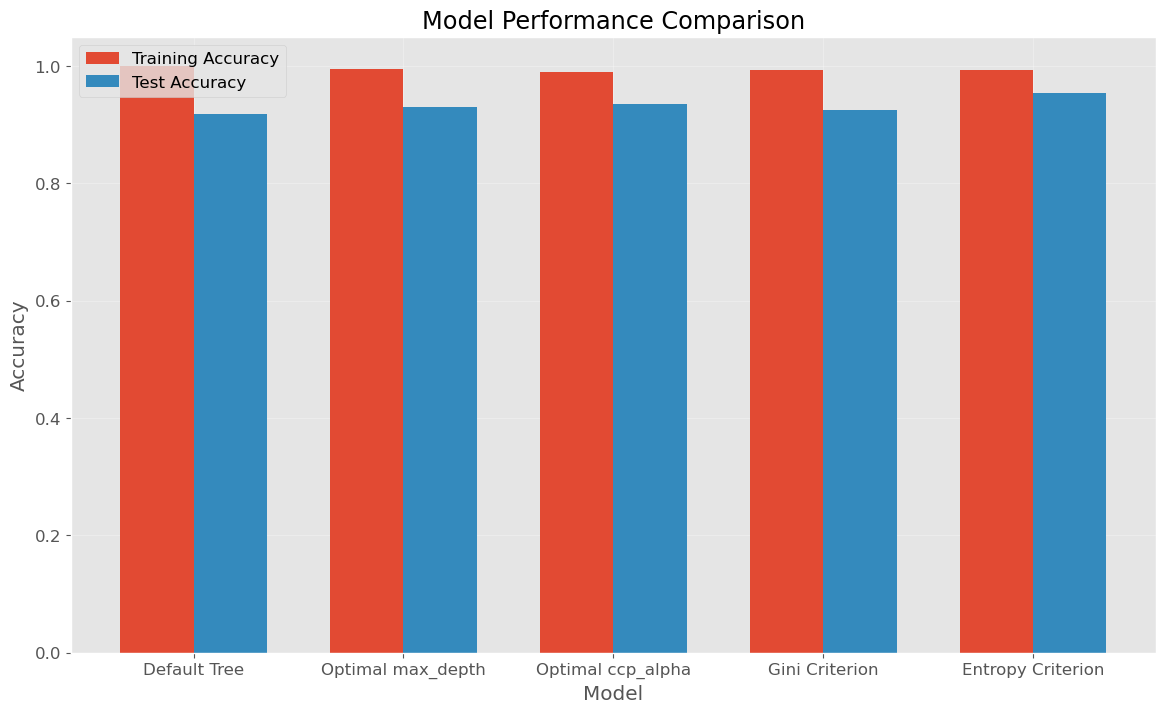


--- End of Day 6.3 Lab ---


In [48]:
# Visualize results
plt.figure(figsize=(14, 8))
x = range(len(results_df))
width = 0.35

plt.bar(x, results_df['Training Accuracy'], width, label='Training Accuracy')
plt.bar([i + width for i in x], results_df['Test Accuracy'], width, label='Test Accuracy')

plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Performance Comparison')
plt.xticks([i + width/2 for i in x], results_df['Model'])
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n--- End of Day 6.3 Lab ---")

### Knowledge Check: Summary and Next Steps
1. Based on our lab results, which complexity control method seems most effective for decision trees?
2. What are the main limitations of decision trees as demonstrated in this lab?
3. How might ensemble methods (coming on Day 7) address some of these limitations?
4. Why is hyperparameter tuning crucial for decision trees more than some other algorithms?
5. What real-world applications would benefit most from decision trees' interpretability?